---
<br>

# Week-03 Day-02 Lab: Statistics (GitHub Repository Dataset)
<br>

---

## **Introduction**
Data preprocessing is one of the most important phases of the data mining process. Before data can be analyzed or used to build predictive models, it must be examined, cleaned, transformed, and prepared. This version of the lab replaces the California Housing dataset with a sample of public GitHub repositories created from 2019 to September 2025. The dataset is the repository-level corpus for our CSCI 4230 research project, Mining GitHub for Unmet Developer Needs.<br>

Students will explore the dataset, identify data quality problems, compute descriptive statistics, evaluate distributions using skewness and kurtosis, and perform common preprocessing techniques used in data mining projects. By the end of the lab, students will transform a raw dataset into a clean and analysis-ready dataset suitable for machine learning and statistical modeling.<br>
<br>

---
## **Objectives**
By the end of this lab, the student will be able to :
* Load a dataset from Google Drive or a local path
* Understand the structure, content, and characteristics of the dataset by examining variables, data types, and overall dataset dimensions.
* Summarize the central tendency and variability of numerical attributes to gain insight into the distribution and behavior of the data.
* Evaluate the shape and spread of data distributions using visualizations and statistical measures such as skewness and kurtosis.
* Identify potential data quality issues, including missing values, duplicates, inconsistencies, and outliers that may affect analysis results.
* Improve dataset quality by handling missing values, removing duplicates, and correcting data issues to create a reliable dataset for analysis.
* Produce a clean, transformed, and analysis-ready dataset.<br>
<br>

---
## **Problem Statement**
Real-world datasets are rarely ready for immediate analysis. They often contain missing values, inconsistent formats, duplicate records, outliers, and variables measured on different scales. These issues can reduce the accuracy and reliability of statistical analyses, data mining techniques, and machine learning models. As a result, data scientists and analysts must preprocess data before conducting meaningful analysis or building predictive models.<br>
<br>

---
## **Additional Resources**
https://TBD
<br>
<br>

---
## **Requirements**
<ol>
  <li>In class, execute all notebook cells.</li>
  <li>.</li>
  <li>.</li>
</ol>
<br>

---
## **Algorithm**
<ol>
  <li>NA.</li>
  <li>NA.</li>
</ol>
<br>

---
## **Application Execution**
<ol>
  <li>NA</li>
  <li>NA</li>
</ol>
<br>

---
## **Lab Structure**
**Section 1**: [Data Dictionary](#p1)

**Section 2**: [Data Understanding](#p2)

**Section 3**: [Data Preparation](#p3)

**Section 4**: [Modeling](#p4)

**Section 5**: [Evaluation](#p5)

**Section 6**: [Conclusion](#p6)

**Section 7**: [Assignment](#p7)
<br>
<br>

<a name="p1"></a>

---

# Section 1: Data Dictionary
---

## **GitHub Repository Dataset**

Each record is one public GitHub repository. The sample covers repositories created from January 1, 2019 to September 27, 2025 with at least 10 stars, not a fork, and a primary language of Python, JavaScript, TypeScript, Go, Rust, or Java. One creation day was drawn at random from each calendar month (random seed 4230), and every qualifying repository created on that day was collected through the GitHub REST search API. The snapshot was taken on September 28, 2026.

| Variable | Description | Data Type | Measurement Scale | Notes |
|-----------|-------------|-----------|-------------------|-------|
| repo_id | GitHub numeric repository ID | Integer | Nominal | Unique key, used as the index |
| full_name | owner/name of the repository | String | Nominal | Identifier, kept for traceability only |
| owner_type | Whether the owner is a user or an organization | String | Nominal | User, Organization |
| language | Primary language detected by GitHub | String | Nominal | Six values, set by the sampling design |
| created_at | Repository creation timestamp (UTC) | Datetime | Interval | ISO 8601 |
| pushed_at | Timestamp of the last push to any branch (UTC) | Datetime | Interval | Proxy for last commit |
| updated_at | Timestamp of the last change to the repository object (UTC) | Datetime | Interval | Changes on stars and settings, not only code |
| stars | Stargazer count | Integer | Ratio | At least 10 by design |
| forks | Fork count | Integer | Ratio | |
| open_issues | Open issues plus open pull requests | Integer | Ratio | GitHub combines both in this field |
| size_kb | Repository size in kilobytes | Integer | Ratio | 0 means an empty repository |
| license | SPDX license identifier | String | Nominal | Missing means no license detected |
| topics | Semicolon-separated topic tags | String | Nominal (set) | Missing means no topics |
| topic_count | Number of topic tags | Integer | Ratio | |
| description | Short repository description | String | Text | Main text field for clustering |
| has_homepage | Homepage URL is set | Boolean | Nominal | |
| has_wiki | Wiki feature enabled | Boolean | Nominal | Enabled by default on new repositories |
| has_pages | GitHub Pages site enabled | Boolean | Nominal | |
| has_discussions | Discussions feature enabled | Boolean | Nominal | |
| archived | Repository is archived (read-only) | Boolean | Nominal | Direct abandonment signal |
| snapshot_date | Date the data was collected | Date | Interval | Constant; reference date for age features |

Variable Classification

Numerical Variables

| Variable | Type | Continuous/Discrete |
|-----------|------|--------------------|
| stars | Numeric | Discrete |
| forks | Numeric | Discrete |
| open_issues | Numeric | Discrete |
| size_kb | Numeric | Discrete |
| topic_count | Numeric | Discrete |

Categorical Variables

| Variable | Category Type |
|-----------|--------------|
| owner_type | Nominal |
| language | Nominal |
| license | Nominal |
| has_homepage, has_wiki, has_pages, has_discussions, archived | Nominal (binary) |

Language Categories

| Category | Description |
|-----------|-------------|
| `Python` | Primary language Python |
| `JavaScript` | Primary language JavaScript |
| `TypeScript` | Primary language TypeScript |
| `Go` | Primary language Go |
| `Rust` | Primary language Rust |
| `Java` | Primary language Java |

Variables Recommended for Statistical Analysis

| Variable | Reason |
|-----------|--------|
| stars | Demand and attention |
| forks | Reuse and derived work |
| open_issues | Unresolved work load |
| size_kb | Project scale |
| topic_count | Self-description effort |
| age_days (derived) | Repository age at snapshot |
| days_since_push (derived) | Main activity signal for abandonment |

Potential Data Quality Issues

| Variable | Potential Issue |
|-----------|----------------|
| description | Missing values; non-English text |
| license | Missing values; `NOASSERTION` placeholder |
| topics | Missing when a repository has no topics |
| stars, forks, open_issues, size_kb | Extreme right skew and outliers |
| size_kb | Zero-size (empty) repositories |
| open_issues | Mixes issues and pull requests |
| stars | Truncated at 10 by the sampling design |
| updated_at | Changes when a repository is starred, so it does not measure maintenance |

Variable Roles for Data Mining

| Variable | Recommended Role |
|-----------|-----------------|
| description, topics | Text input for problem clustering (RQ1) |
| stars, forks, open_issues, size_kb, topic_count, owner_type, language, license, boolean flags | Predictors for the abandonment classifier (RQ2) |
| pushed_at, archived, days_since_push, active_span_days | Used to build the target label, or exactly recover it from age_days; excluded as predictors to avoid leakage |
| maintenance_status (derived) | Target variable for classification |
| full_name, repo_id | Identifiers only |

Target Variable

| Variable | Role |
|-----------|------|
| maintenance_status | Derived label (abandoned, maintained, unlabeled) for the RQ2 classifier |

Data Mining Perspective

| Variable Group | Recommendation |
|----------------|---------------|
| Popularity Variables | Log-transform before parametric analysis |
| Activity Variables | Derive ages from timestamps relative to the snapshot date |
| Text Variables | Clean and keep for clustering; not used in this lab's statistics |
| Categorical Variables | Encode prior to machine learning algorithms |

<a name="p2"></a>

---

# Section 2: Data Understanding
---

## Step 1: Data Collection

In [30]:
# S2.S1.1) Import(s) for Lab

import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import probplot, boxcox
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

graph_color = '#312af7'
edgecolor = '#BB8FCE'

print('Imports Complete')

Imports Complete


In [31]:
# S2.S1.2) Load Google Drive helper (falls back to a local path outside Colab)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

In [32]:
# S2.S1.3) Load the Data

# Set a path to data
if IN_COLAB:
    my_path = '/content/drive/My Drive/Data-Mining/Labs/Week-3-Lab/github_repos_2019_2025.csv'
else:
    my_path = 'github_repos_2019_2025.csv'

# Load data into dataframe
df = pd.read_csv(my_path, index_col='repo_id')

# Check the dataframe
print(df.shape)
df.dtypes

(25173, 20)


full_name            str
owner_type           str
language             str
created_at           str
pushed_at            str
updated_at           str
stars              int64
forks              int64
open_issues        int64
size_kb            int64
license              str
topics               str
topic_count        int64
description          str
has_homepage        bool
has_wiki            bool
has_pages           bool
has_discussions     bool
archived            bool
snapshot_date        str
dtype: object

## Step 2: Data Validation

In [33]:
# S2.S2.1 Describe Data

print()
print(df.index)
print()
df.info()
print()
display(df.head())
print()
display(df.tail())


Index([ 165990457,  165957180,  166091373,  165960557,  166055089,  166048649,
        166004555,  165984386,  166009883,  166033886,
       ...
       1064199893, 1064333192, 1063688623, 1063833022, 1063892503, 1063821063,
       1064186734, 1064321320, 1064007526, 1063656582],
      dtype='int64', name='repo_id', length=25173)

<class 'pandas.DataFrame'>
Index: 25173 entries, 165990457 to 1063656582
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   full_name        25173 non-null  str  
 1   owner_type       25173 non-null  str  
 2   language         25109 non-null  str  
 3   created_at       25173 non-null  str  
 4   pushed_at        25173 non-null  str  
 5   updated_at       25173 non-null  str  
 6   stars            25173 non-null  int64
 7   forks            25173 non-null  int64
 8   open_issues      25173 non-null  int64
 9   size_kb          25173 non-null  int64
 10  license          15361 non-n

,full_name,owner_type,language,created_at,pushed_at,updated_at,stars,forks,open_issues,size_kb,license,topics,topic_count,description,has_homepage,has_wiki,has_pages,has_discussions,archived,snapshot_date
repo_id,,,,,,,,,,,,,,,,,,,,
165990457,Jinnrry/getAwayBSG,User,Go,2019-01-16T06:56:14Z,2019-09-05T15:10:49Z,2026-09-28T12:56:39Z,1148,116,8,698,AGPL-3.0,NaN,0,逃离北上广,True,True,True,False,True,2026-09-28
165957180,pingcap/dm,Organization,Go,2019-01-16T02:13:45Z,2022-05-09T08:28:36Z,2026-09-24T09:51:12Z,454,189,127,23101,Apache-2.0,hacktoberfest,1,Data Migration Platform,False,True,False,False,True,2026-09-28
166091373,assafmo/xioc,User,Go,2019-01-16T18:38:35Z,2020-04-19T17:42:40Z,2026-08-10T15:37:37Z,163,9,4,66,MIT,command-line;command-line-tool;data-mining;def...,14,"Extract indicators of compromise from text, in...",False,True,False,False,False,2026-09-28
165960557,naqvijafar91/cuteDB,User,Go,2019-01-16T02:37:59Z,2022-06-26T22:31:19Z,2026-02-01T11:38:01Z,150,26,5,727,NaN,database;embedded-database;go;golang;key-value...,8,A slick BTree on disk based key value store im...,False,True,False,False,False,2026-09-28
166055089,giongto35/gowog,User,Go,2019-01-16T14:36:47Z,2019-05-09T14:55:57Z,2026-08-15T13:30:25Z,126,30,0,7951,MIT,game;game-2d;golang;online-game;phaser;webgame...,7,"Gowog, Golang based Web multiplayer Online Game",True,True,False,False,False,2026-09-28


,full_name,owner_type,language,created_at,pushed_at,updated_at,stars,forks,open_issues,size_kb,license,topics,topic_count,description,has_homepage,has_wiki,has_pages,has_discussions,archived,snapshot_date
repo_id,,,,,,,,,,,,,,,,,,,,
1063821063,copilotkit-support/AI-Shopping-Agent,User,TypeScript,2025-09-25T06:56:50Z,2025-10-01T15:19:48Z,2025-12-28T04:21:31Z,10,1,0,7978,NaN,NaN,0,NaN,True,True,False,False,False,2026-09-28
1064186734,Vocawiki/wiki-frontend,Organization,TypeScript,2025-09-25T17:03:15Z,2026-09-27T00:28:02Z,2026-09-27T00:28:06Z,10,1,2,843,NOASSERTION,NaN,0,Vocawiki（ https://voca.wiki ）Gadget、Widget等代码,True,True,False,False,False,2026-09-28
1064321320,pix3dev/pix3,Organization,TypeScript,2025-09-25T21:30:17Z,2026-09-28T14:32:32Z,2026-09-28T14:32:38Z,10,0,0,66034,Apache-2.0,NaN,0,PlayableAds and web games AI Agents first editor,True,True,True,False,False,2026-09-28
1064007526,Haider-Mukhtar/ReactNative-Apple-Health-IOS,User,TypeScript,2025-09-25T12:15:05Z,2025-09-27T06:37:38Z,2026-08-06T18:16:13Z,10,2,0,1162,MIT,applehealth;expo;ios;react-native;react-native...,6,Integration of Apple Health with React Native ...,False,True,False,False,False,2026-09-28
1063656582,better-auth-extended/dashboard,Organization,TypeScript,2025-09-25T00:05:24Z,2025-10-09T22:11:35Z,2026-08-17T21:29:18Z,10,0,0,429,MIT,better-auth;better-auth-admin;better-auth-dash...,4,A Better-Auth powered admin dashboard.,True,False,False,False,False,2026-09-28


## Step 3: Describing Data

In [34]:
# S2.Step3.1 Frequency

# Frequency tables all attributes
for col in df.select_dtypes(include='number').columns:
    print(f"\n{'='*60}")
    print(f"Frequency Table: {col}")
    print(f"{'='*60}")

    freq = pd.cut(df[col], bins=10).value_counts().sort_index()

    display(freq.to_frame(name='Frequency'))


Frequency Table: stars


,Frequency
stars,
"(-100.845, 11094.5]",25134
"(11094.5, 22179.0]",20
"(22179.0, 33263.5]",7
"(33263.5, 44348.0]",5
"(44348.0, 55432.5]",1
"(55432.5, 66517.0]",3
"(66517.0, 77601.5]",1
"(77601.5, 88686.0]",0
"(88686.0, 99770.5]",1



Frequency Table: forks


,Frequency
forks,
"(-25.05, 2505.0]",25145
"(2505.0, 5010.0]",13
"(5010.0, 7515.0]",7
"(7515.0, 10020.0]",5
"(10020.0, 12525.0]",1
"(12525.0, 15030.0]",0
"(15030.0, 17535.0]",1
"(17535.0, 20040.0]",0
"(20040.0, 22545.0]",0



Frequency Table: open_issues


,Frequency
open_issues,
"(-9.433, 943.3]",25161
"(943.3, 1886.6]",7
"(1886.6, 2829.9]",1
"(2829.9, 3773.2]",0
"(3773.2, 4716.5]",0
"(4716.5, 5659.8]",1
"(5659.8, 6603.1]",2
"(6603.1, 7546.4]",0
"(7546.4, 8489.7]",0



Frequency Table: size_kb


,Frequency
size_kb,
"(-27295.925, 2729592.5]",25141
"(2729592.5, 5459185.0]",16
"(5459185.0, 8188777.5]",8
"(8188777.5, 10918370.0]",4
"(10918370.0, 13647962.5]",0
"(13647962.5, 16377555.0]",0
"(16377555.0, 19107147.5]",0
"(19107147.5, 21836740.0]",2
"(21836740.0, 24566332.5]",0



Frequency Table: topic_count


,Frequency
topic_count,
"(-0.02, 2.0]",16102
"(2.0, 4.0]",2966
"(4.0, 6.0]",2466
"(6.0, 8.0]",1446
"(8.0, 10.0]",806
"(10.0, 12.0]",512
"(12.0, 14.0]",288
"(14.0, 16.0]",210
"(16.0, 18.0]",149


In [35]:
# S2.Step3.2 Frequency

# Frequency table single attribute
freq_table = df['language'].value_counts().reset_index()

freq_table.columns = ['Language', 'Frequency']

display(freq_table)

,Language,Frequency
0,Python,11378
1,JavaScript,4684
2,TypeScript,4137
3,Java,1850
4,Go,1713
5,Rust,1347


In [36]:
# S2.Step3.3 Frequency

# Frequency and percentage table single attribute
for col in ['language', 'owner_type', 'license']:
    freq_table = pd.DataFrame({
        'Frequency': df[col].value_counts(dropna=False),
        'Percentage': round(
            df[col].value_counts(normalize=True, dropna=False) * 100,
            2
        )
    })
    print(f"\n{col}")
    display(freq_table.head(12))


language


,Frequency,Percentage
language,,
Python,11378,45.20
JavaScript,4684,18.61
TypeScript,4137,16.43
Java,1850,7.35
Go,1713,6.80
Rust,1347,5.35
NaN,64,0.25



owner_type


,Frequency,Percentage
owner_type,,
User,18577,73.8
Organization,6596,26.2



license


,Frequency,Percentage
license,,
NaN,9812,38.98
MIT,8462,33.62
Apache-2.0,2785,11.06
GPL-3.0,1481,5.88
NOASSERTION,1127,4.48
AGPL-3.0,363,1.44
BSD-3-Clause,303,1.20
MPL-2.0,124,0.49
GPL-2.0,118,0.47


In [37]:
# S2.Step3.4 Numerical Measures

# Set global display precision to 2 decimal places
# pd.set_option('display.precision', 2)
pd.reset_option('display.precision')


df.describe()

,stars,forks,open_issues,size_kb,topic_count
count,25173.000000,25173.000000,25173.000000,2.517300e+04,25173.000000
mean,154.188456,28.480475,8.509355,3.391584e+04,2.551583
std,1551.938735,278.830886,94.947066,3.655109e+05,4.016632
min,10.000000,0.000000,0.000000,0.000000e+00,0.000000
25%,14.000000,2.000000,0.000000,1.590000e+02,0.000000
50%,23.000000,5.000000,1.000000,1.201000e+03,0.000000
75%,56.000000,13.000000,5.000000,9.017000e+03,4.000000
max,110855.000000,25050.000000,9433.000000,2.729592e+07,20.000000


In [38]:
# S2.Step3.5 Mode

for col in df.columns:
  print(f"\nColumn: {col}")
  print(f"Mode(s): {list(df[col].mode())[:5]}")


Column: full_name
Mode(s): ['01-DC/video-keyframe-extractor', '011235813/SEPT', '01one/AndroidWebviewTemplate', '01studio-lab/MicroPython_Examples', '030/n3dr']

Column: owner_type
Mode(s): ['User']

Column: language
Mode(s): ['Python']

Column: created_at
Mode(s): ['2019-02-23T19:23:24Z', '2019-04-24T18:54:12Z', '2019-07-17T04:45:20Z', '2019-07-17T11:07:28Z', '2019-07-17T14:51:12Z']

Column: pushed_at
Mode(s): ['2023-01-19T12:40:26Z']

Column: updated_at
Mode(s): ['2025-02-27T09:14:36Z']

Column: stars
Mode(s): [10]

Column: forks
Mode(s): [0]

Column: open_issues
Mode(s): [0]

Column: size_kb
Mode(s): [3]

Column: license
Mode(s): ['MIT']

Column: topics
Mode(s): ['hacktoberfest']

Column: topic_count
Mode(s): [0]

Column: description
Mode(s): ['Vonssy Part 2?']

Column: has_homepage
Mode(s): [False]

Column: has_wiki
Mode(s): [True]

Column: has_pages
Mode(s): [False]

Column: has_discussions
Mode(s): [False]

Column: archived
Mode(s): [False]

Column: snapshot_date
Mode(s): ['2026

In [39]:
# S2.Step3.6 More Descriptive Statistics

# Select only numeric columns
numeric_df = df.select_dtypes(include = 'number')
# print(numeric_df)

# Display settings for wide tables in Colab
pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.width', 2000)

# Create a summary table
summary = pd.DataFrame({
    'Mean': numeric_df.mean(),
    'Mode': numeric_df.mode().iloc[0],  # First mode if multiple modes exist
    'Median': numeric_df.median(),
    'Min': numeric_df.min(),
    'Max': numeric_df.max(),
    'Range': numeric_df.max() - numeric_df.min(),
    'Variance': numeric_df.var(),
    'Std_Dev': numeric_df.std(),
    'Q1': numeric_df.quantile(0.25),
    'Q3': numeric_df.quantile(0.75),
    'IQR': numeric_df.quantile(0.75) - numeric_df.quantile(0.25),
    'Skewness': numeric_df.skew(),
    'Kurtosis': numeric_df.kurt()
})

# Round results for readability
summary = summary.round(2)

print(summary)

                 Mean  Mode  Median  Min       Max     Range      Variance    Std_Dev     Q1      Q3     IQR  Skewness  Kurtosis
stars          154.19    10    23.0   10    110855    110845  2.408514e+06    1551.94   14.0    56.0    42.0     40.53   2169.77
forks           28.48     0     5.0    0     25050     25050  7.774666e+04     278.83    2.0    13.0    11.0     48.06   3297.39
open_issues      8.51     0     1.0    0      9433      9433  9.014950e+03      94.95    0.0     5.0     5.0     68.99   5665.05
size_kb      33915.84     3  1201.0    0  27295925  27295925  1.335982e+11  365510.88  159.0  9017.0  8858.0     47.96   2950.61
topic_count      2.55     0     0.0    0        20        20  1.613000e+01       4.02    0.0     4.0     4.0      1.90      3.72


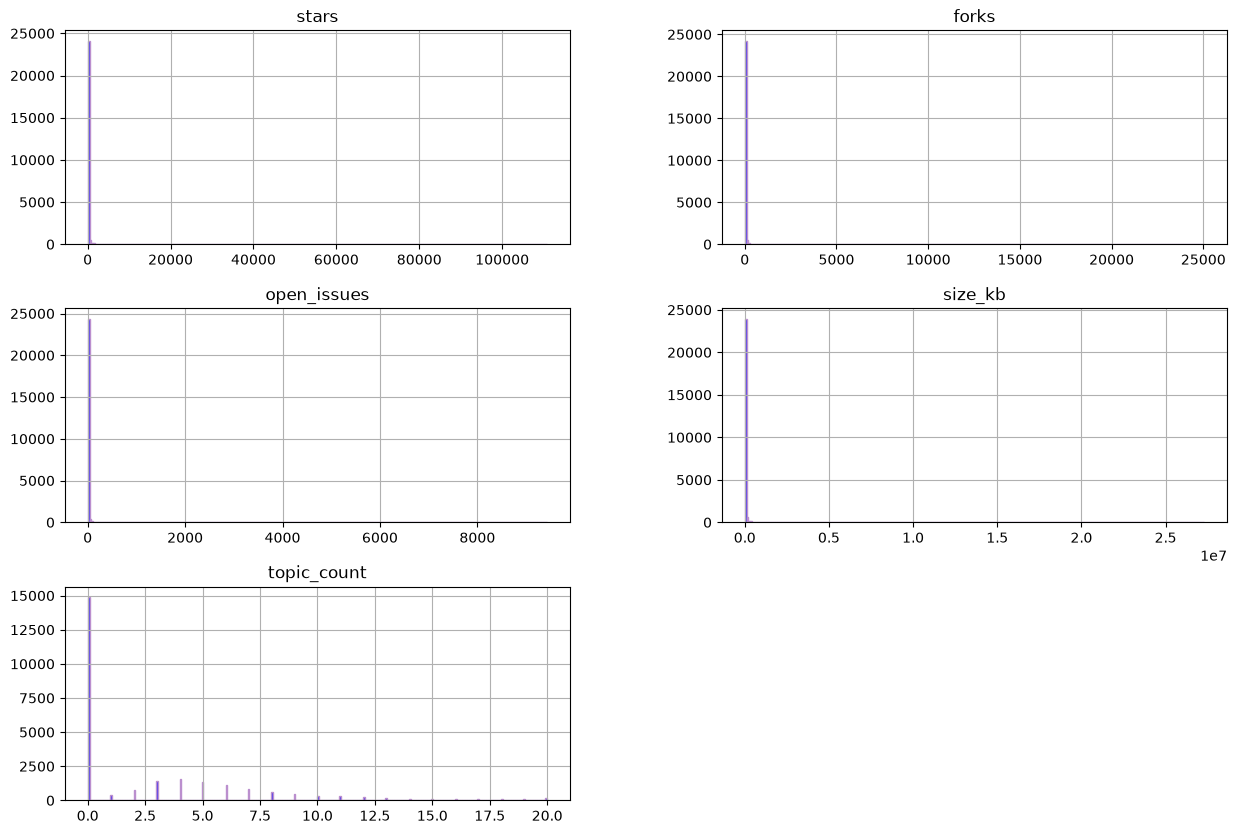

In [40]:
df.hist(bins=250, figsize=(15, 10), color=graph_color, edgecolor=edgecolor)
plt.show()

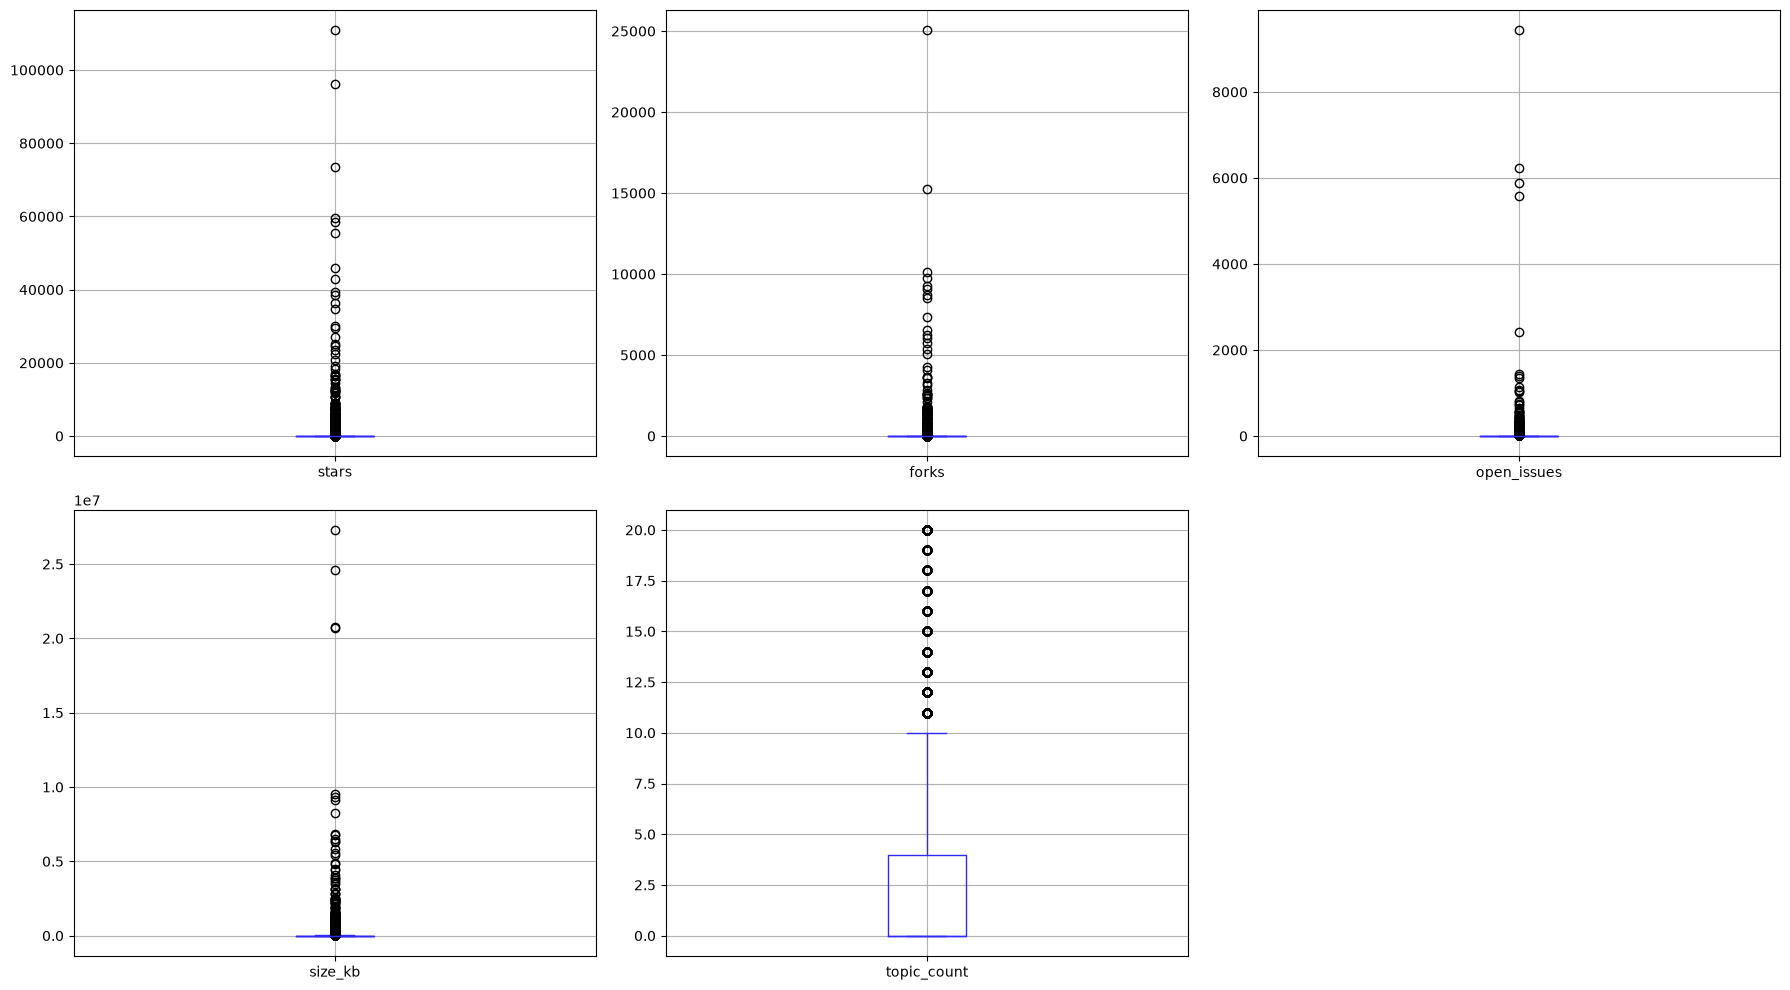

In [41]:
# Boxplots for the numeric columns
num_cols = df.select_dtypes(include='number').columns
ncols = 3
nrows = -(-len(num_cols) // ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5 * nrows))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    df.boxplot(column=col, ax=ax, color=graph_color)

for i in range(len(num_cols), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

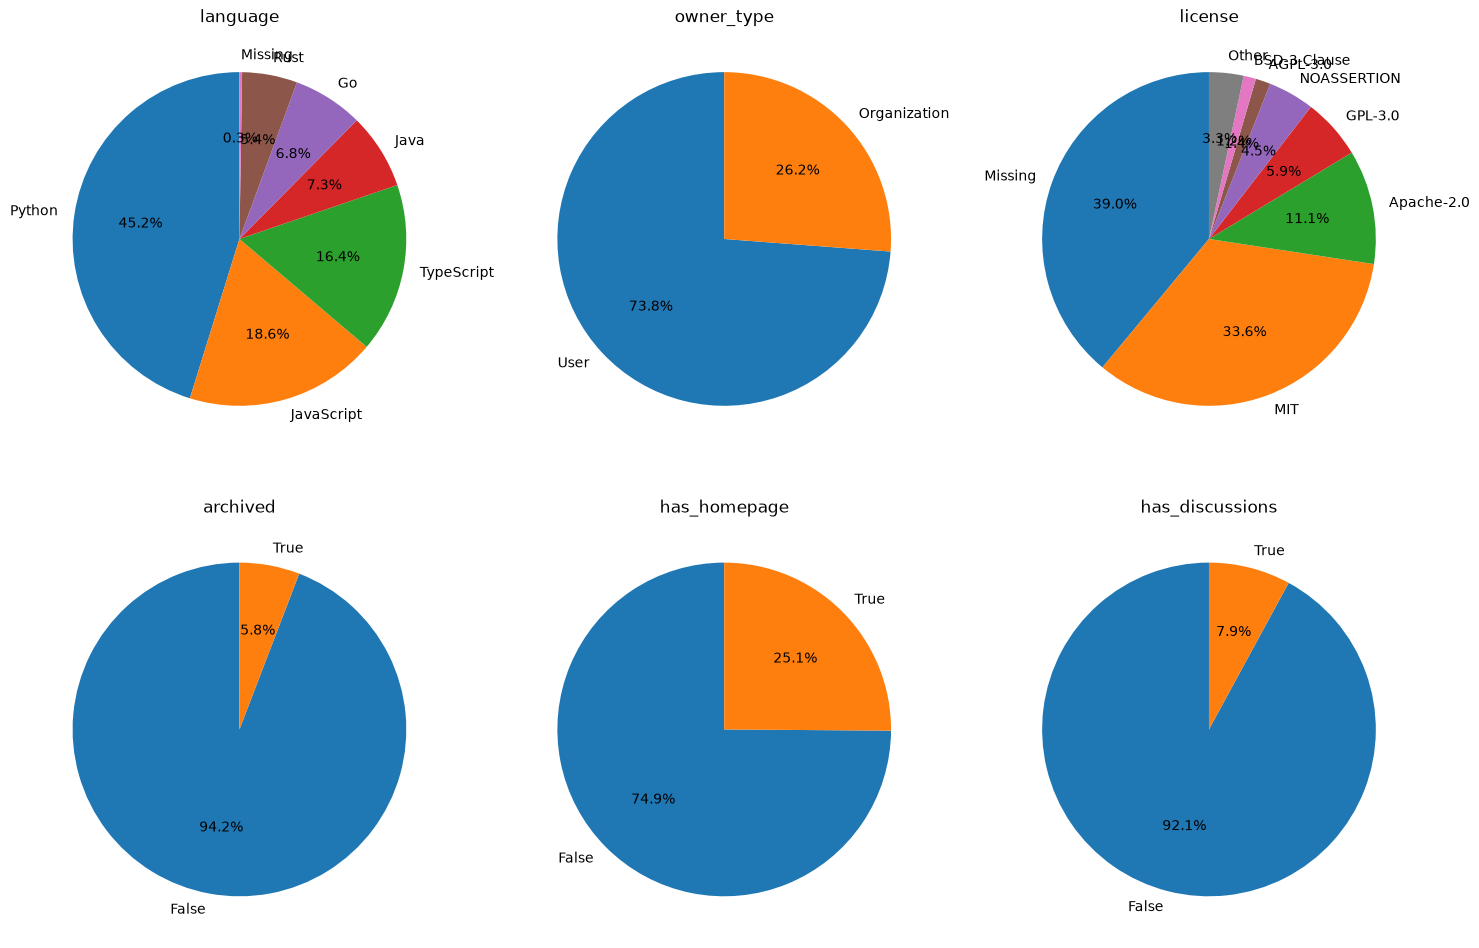

In [42]:
# Select low-cardinality categorical columns (full_name, description, and topics are free text)
cat_cols = ['language', 'owner_type', 'license', 'archived', 'has_homepage', 'has_discussions']

ncols = 3
nrows = (len(cat_cols) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 5 * nrows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = df[col].fillna('Missing').astype(str).value_counts()

    # Group the long tail of licenses so the chart stays readable
    if len(counts) > 8:
        counts = pd.concat([counts.iloc[:7], pd.Series({'Other': counts.iloc[7:].sum()})])

    axes[i].pie(
        counts,
        labels=counts.index,
        autopct='%1.1f%%',
        startangle=90
    )

    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Initial Data Investigation Findings
- The raw file has 25,173 rows and 21 columns. `repo_id` is used as the index, so the dataframe has 20 columns.
- Sixteen columns are text or timestamps stored as strings. The timestamps are converted to datetimes in Section 3, Step 3.
- All five count variables are strongly right skewed. Skewness ranges from 1.90 for `topic_count` to 68.99 for `open_issues`, and kurtosis for `stars` is 2,169.77. Medians sit far below means (stars: median 23, mean 154).
- The minimum for `stars` is 10 because of the sampling design, so that variable is truncated on the left.
- Missing values are common. About 39% of repositories have no license, 59% have no topics, and 16% have no description.
- Python accounts for 45% of repositories and JavaScript for 19%. Individual users own 74% of repositories.
- 73 repositories (0.29%) in the raw file have a last push earlier than their creation date. Most of them also have no language, so cleaning removes all but 6. This happens when a repository is created from imported history.
- The California Housing columns were mostly continuous measurements. Here the numeric columns are counts, and most of the descriptive content is text or categorical.

<a name="p3"></a>

---

# Section 3: Data Preparation
---

## Step 1: Missing Values

In [43]:
# S3.Step1.1 Check for missing values

df.isnull().any()

full_name          False
owner_type         False
language            True
created_at         False
pushed_at          False
updated_at         False
stars              False
forks              False
open_issues        False
size_kb            False
license             True
topics              True
topic_count        False
description         True
has_homepage       False
has_wiki           False
has_pages          False
has_discussions    False
archived           False
snapshot_date      False
dtype: bool

In [44]:
# S3.Step1.2 Missing value counts and percentages

missing = pd.DataFrame({
    'Missing': df.isnull().sum(),
    'Percent': round(df.isnull().mean() * 100, 2)
})
display(missing[missing['Missing'] > 0])

# View rows where 'description' is null
display(df[df['description'].isnull()].head())

,Missing,Percent
language,64,0.25
license,9812,38.98
topics,14920,59.27
description,3951,15.70


,full_name,owner_type,language,created_at,pushed_at,updated_at,stars,forks,open_issues,size_kb,license,topics,topic_count,description,has_homepage,has_wiki,has_pages,has_discussions,archived,snapshot_date
repo_id,,,,,,,,,,,,,,,,,,,,
165984386,Meituan-Dianping/cat-go,Organization,Go,2019-01-16T06:09:30Z,2023-04-03T03:30:59Z,2025-08-05T06:12:31Z,55,27,6,62,Apache-2.0,NaN,0,NaN,False,True,True,False,False,2026-09-28
172180920,fakeboboliu/wenku8epub,User,Go,2019-02-23T06:38:09Z,2021-09-09T14:28:21Z,2023-09-23T03:16:55Z,19,2,0,27,WTFPL,NaN,0,NaN,False,True,False,False,False,2026-09-28
172186377,fkfk000/simpleRPC,User,Go,2019-02-23T07:41:15Z,2019-02-23T08:19:40Z,2025-05-13T14:11:28Z,14,3,0,8,NaN,NaN,0,NaN,False,True,False,False,False,2026-09-28
176771010,gobuffalo/clara,Organization,Go,2019-03-20T16:08:52Z,2022-10-07T03:36:12Z,2022-07-28T23:20:49Z,11,3,0,172,MIT,go;golang,2,NaN,False,True,False,False,False,2026-09-28
185006767,rubyhan1314/go_foundation,User,Go,2019-05-05T09:03:31Z,2019-06-19T06:07:30Z,2025-08-25T16:46:55Z,60,36,0,4375,NaN,NaN,0,NaN,False,True,False,False,False,2026-09-28


Four columns contain missing values: `language` (64 rows, 0.25%), `license` (9,812 rows, 38.98%), `topics` (14,920 rows, 59.27%), and `description` (3,951 rows, 15.70%).

What to do with missing data?

| Variable | Decision | Reason |
|-----------|----------|--------|
| description | Drop the row | Description is the main clustering input for RQ1. Imputing text would invent content. |
| language | Drop the row | The sampling design guarantees one of six languages. A missing value means the repository's language changed after it matched the search, so its true group is unknown. |
| license | Impute `None` | A missing license means GitHub found no license file. That is information, not a gap. `NOASSERTION` (a license file GitHub could not classify) becomes `Other`. |
| topics | Impute empty string | A missing value means the repository has no topics. `topic_count` is already 0 for these rows. |

In [45]:
# S3.Step1.3 Handle missing values

df = df.dropna(subset=['description', 'language'])
df['license'] = df['license'].fillna('None').replace('NOASSERTION', 'Other')
df['topics'] = df['topics'].fillna('')

df.isnull().sum()

full_name          0
owner_type         0
language           0
created_at         0
pushed_at          0
updated_at         0
stars              0
forks              0
open_issues        0
size_kb            0
license            0
topics             0
topic_count        0
description        0
has_homepage       0
has_wiki           0
has_pages          0
has_discussions    0
archived           0
snapshot_date      0
dtype: int64

## Step 2: Drop duplicate data

In [46]:
# S3.Step2.1 Duplicate Data

print('Duplicate repo_id values:', df.index.duplicated().sum())
print('Duplicate full_name values:', df['full_name'].duplicated().sum())
print('Fully duplicated rows:', df.duplicated().sum())

df = df[~df.index.duplicated()]
df = df.drop_duplicates()
print(df.shape)

Duplicate repo_id values: 0
Duplicate full_name values: 0
Fully duplicated rows: 0
(21164, 20)


There are no duplicate `repo_id` values, no duplicate `full_name` values, and no fully duplicated rows. The step is kept so the workflow is complete. After the missing-value step the dataframe has 21,164 rows.

Next, remove records that cannot support the research questions. Empty repositories (`size_kb` equal to 0) have no code to maintain. Repositories whose description is mostly non-Latin text are out of scope because the proposal limits clustering to English text. The check below uses the share of letters that are ASCII as a lightweight proxy for a language detector.

In [47]:
# S3.Step2.2 Remove empty repositories and non-English descriptions

def ascii_letter_share(text):
    letters = [ch for ch in text if ch.isalpha()]
    if not letters:
        return 0.0
    return sum(ch.isascii() for ch in letters) / len(letters)

df['ascii_share'] = df['description'].apply(ascii_letter_share)

print('Empty repositories:', (df['size_kb'] == 0).sum())
print('Mostly non-English descriptions:', (df['ascii_share'] < 0.9).sum())
display(df.loc[df['ascii_share'] < 0.9, ['full_name', 'description']].head())

df = df[(df['size_kb'] > 0) & (df['ascii_share'] >= 0.9)].drop(columns='ascii_share')
print(df.shape)

Empty repositories: 7
Mostly non-English descriptions: 2291


,full_name,description
repo_id,,
165990457,Jinnrry/getAwayBSG,逃离北上广
176710234,tyz910/golang-webservices,🎓 Разработка веб-сервисов на Golang
176661293,aprilmadaha/pingmesh,Pingmesh:A Large-Scale System for Data Center ...
176663712,kirinlabs/utils,Golang开发扩展库，包括字符串处理、日期转换、类型转换、切片处理、压缩、加密、AES/E...
176756424,qq1060656096/gapp,go gin应用


(18866, 20)


Seven repositories were empty and 2,291 had descriptions that were mostly non-ASCII text. After both filters the dataframe has 18,866 rows. In total 6,307 rows (25.1%) were removed from the raw file, most of them for a missing description. The ASCII check is a rough proxy. It can remove descriptions that mix English and another language, and it keeps non-English text written in Latin letters. The proposal calls for a language detector, which should replace this check before the clustering work.

Unlike the housing data, the extreme values in `stars`, `forks`, and `open_issues` are real observations, not capped or erroneous values. A few repositories become very popular. Removing them would remove the demand signal the project needs, so they are kept and handled with a log transform in Step 8.

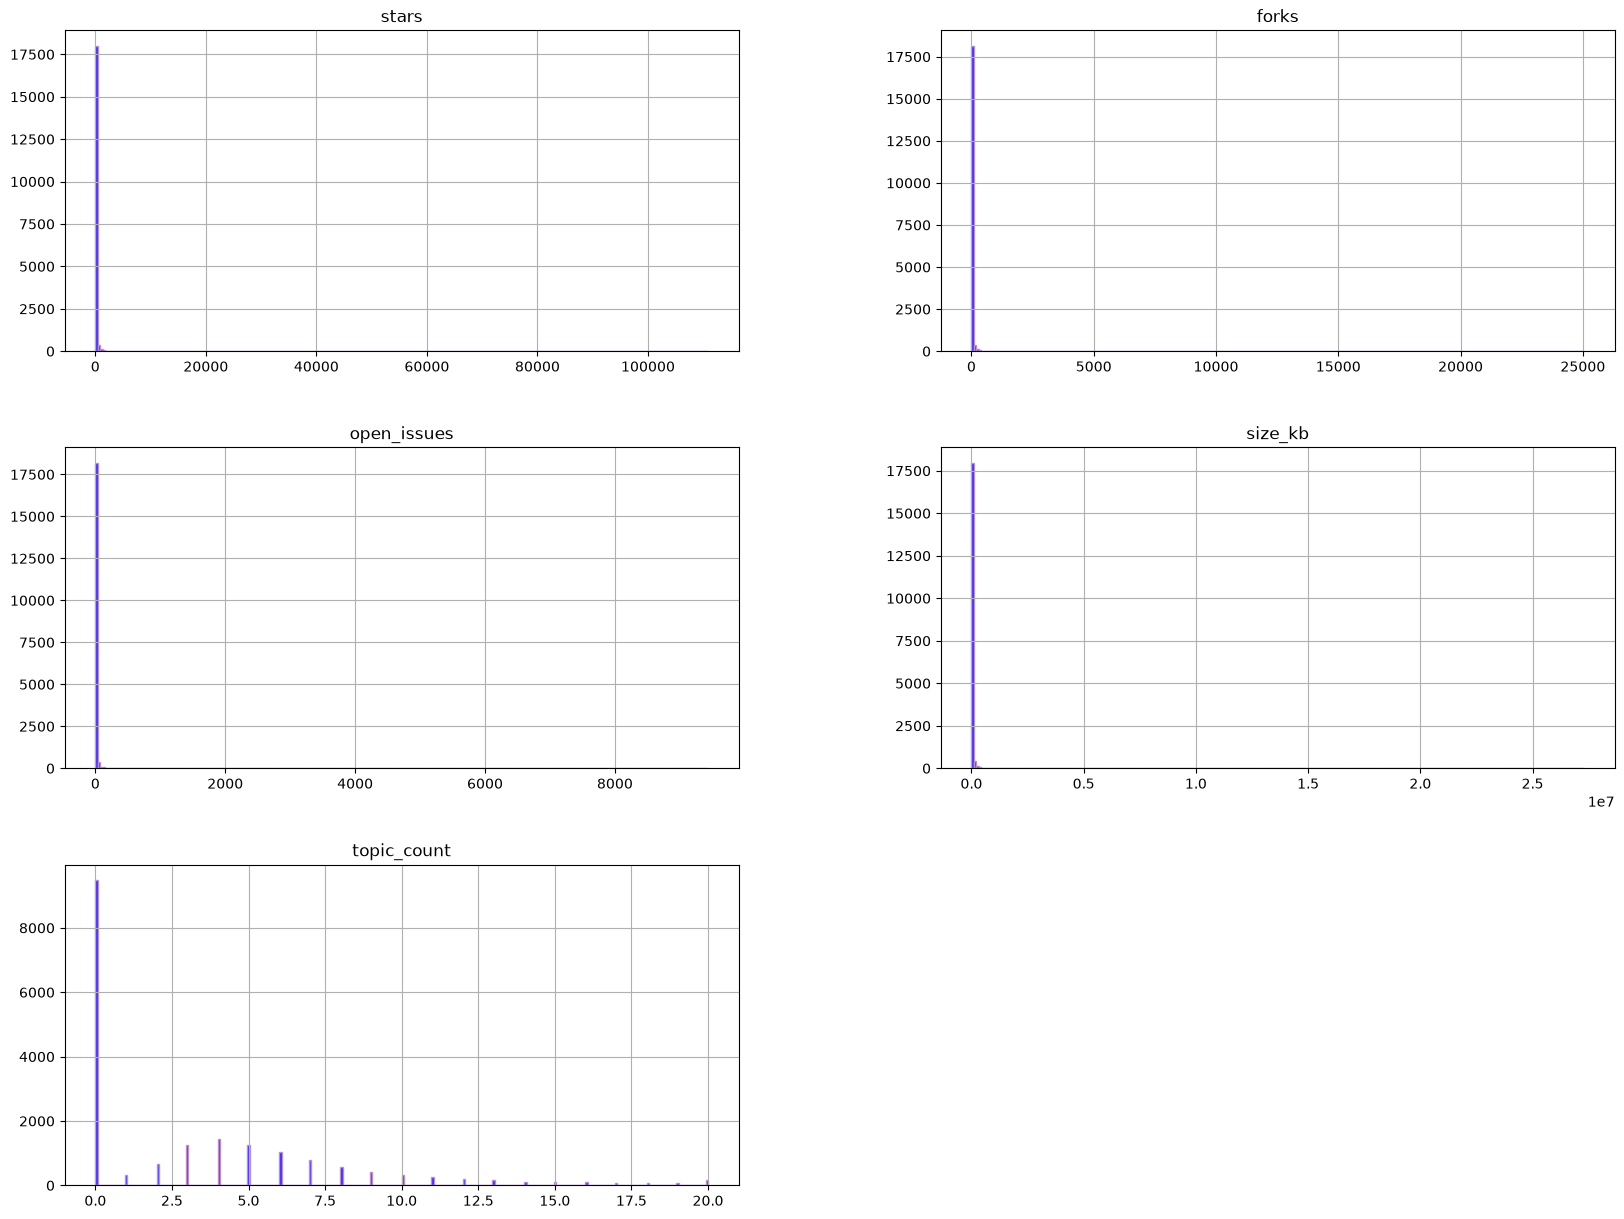

In [48]:
df.hist(bins=250, figsize=(20, 15), color=graph_color, edgecolor=edgecolor);
plt.show()

## Step 3: Prepare Data for Inferential Statistics

Timestamps are converted to datetimes and turned into numeric features measured against the snapshot date, so every age is reproducible from the saved file. The abandonment label follows the rules in the research proposal (after Coelho et al., 2020), with one adjustment: the search API does not return maintainer response times, so the "no maintainer response" condition is approximated by open issues or pull requests remaining.

| Label | Rule |
|-------|------|
| abandoned | Archived, or no push in more than 365 days while `open_issues` is above 0 |
| maintained | Not archived and a push within the last 90 days |
| unlabeled | Everything else; excluded from classifier training |

For the California Housing dataset, the inferential section used the raw numeric columns. For this dataset it uses the counts plus the derived activity variables:
    'stars',
    'forks',
    'open_issues',
    'size_kb',
    'topic_count',
    'age_days',
    'days_since_push',
    'active_span_days'

In [49]:
# S3.Step3.1 Import(s)

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import shapiro

from scipy import stats

In [50]:
# S3.Step3.2 Derive activity features and define attributes

for col in ['created_at', 'pushed_at', 'updated_at']:
    df[col] = pd.to_datetime(df[col], utc=True)
snapshot = pd.to_datetime(df['snapshot_date'].iloc[0], utc=True)

df['age_days'] = (snapshot - df['created_at']).dt.days
df['days_since_push'] = (snapshot - df['pushed_at']).dt.days.clip(lower=0)
df['active_span_days'] = (df['pushed_at'] - df['created_at']).dt.days.clip(lower=0)
df['created_year'] = df['created_at'].dt.year

stale = (df['days_since_push'] > 365) & (df['open_issues'] > 0)
df['maintenance_status'] = np.select(
    [df['archived'] | stale, df['days_since_push'] <= 90],
    ['abandoned', 'maintained'],
    default='unlabeled'
)

numeric_cols = [
    'stars',
    'forks',
    'open_issues',
    'size_kb',
    'topic_count',
    'age_days',
    'days_since_push',
    'active_span_days'
]

numeric_df = df[numeric_cols]
display(df['maintenance_status'].value_counts().to_frame('Frequency'))

,Frequency
maintenance_status,
abandoned,8074
unlabeled,7465
maintained,3327


In [51]:
# S3.Step3.3 Confirm the working dataframe

# The template reloaded the raw CSV here, which would undo the cleaning above.
# The cleaned dataframe is used instead.
print(df.shape)
print('Data Ready')

(18866, 25)
Data Ready


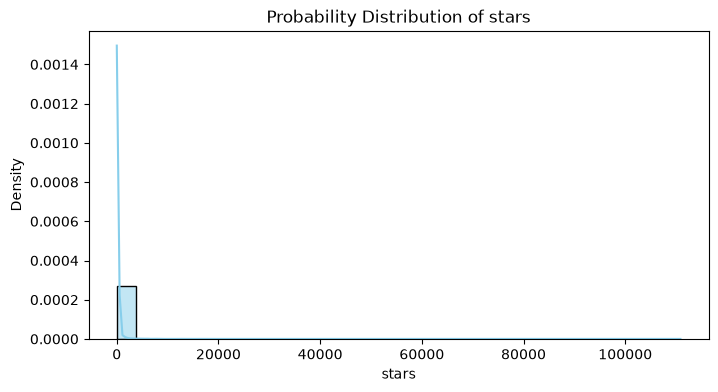

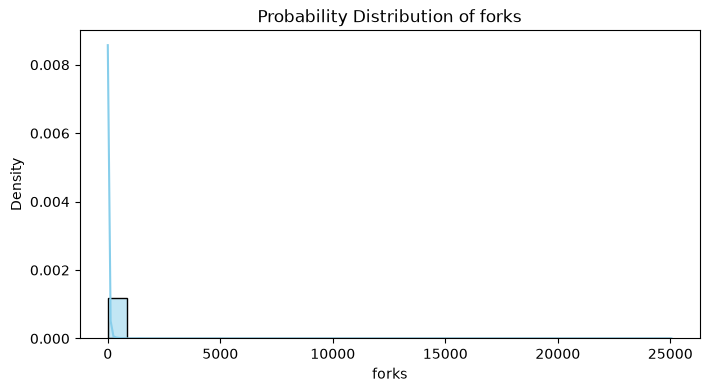

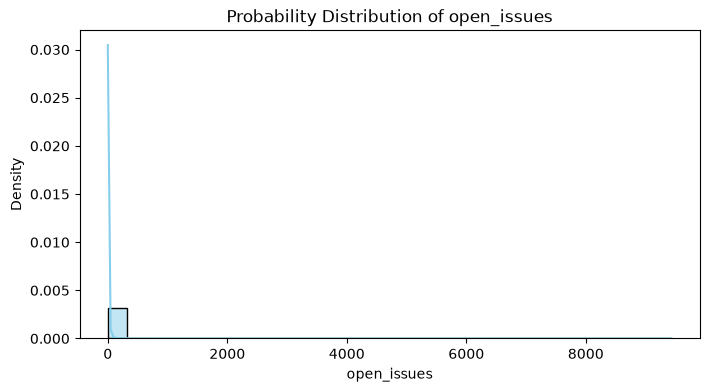

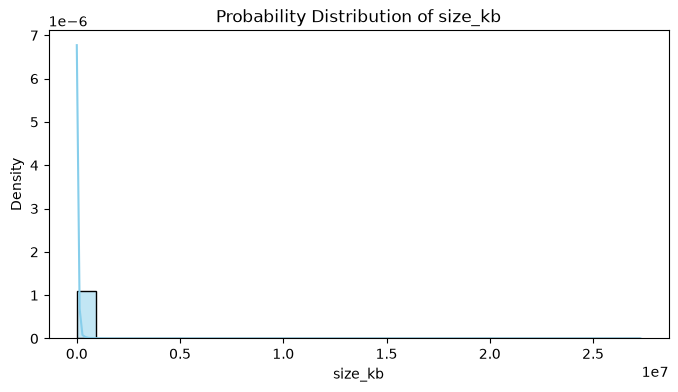

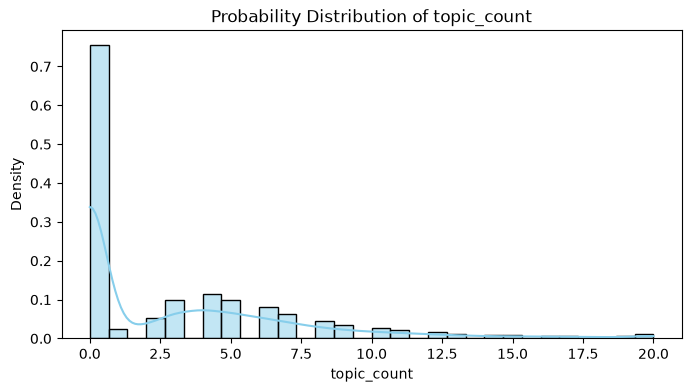

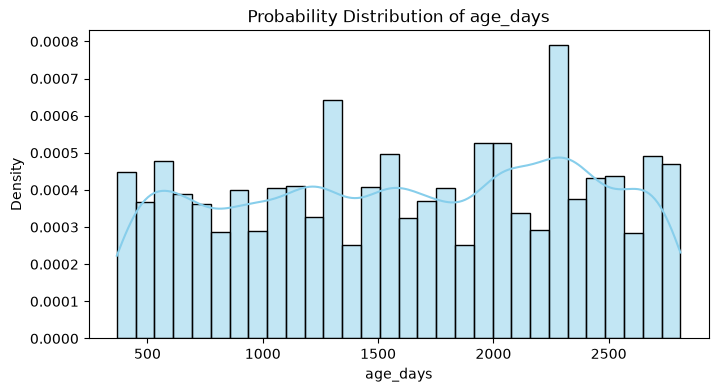

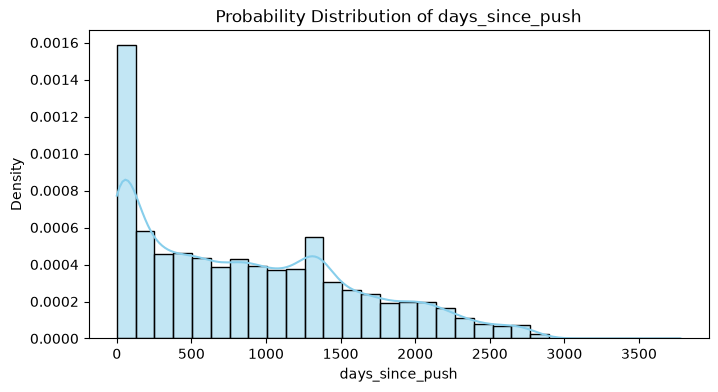

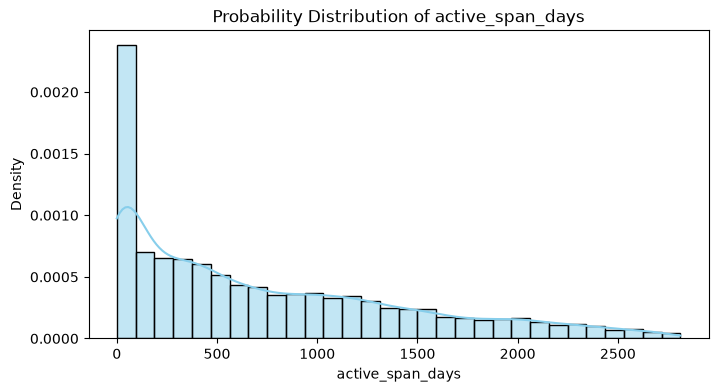

In [52]:
# S3.Step3.4 Probability Distributions

for col in numeric_df.columns:

    plt.figure(figsize=(8,4))

    sns.histplot(
        numeric_df[col].dropna(),
        bins=30,
        kde=True,
        stat='density',
        color='skyblue'
    )

    plt.title(f'Probability Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Density')

    plt.show()

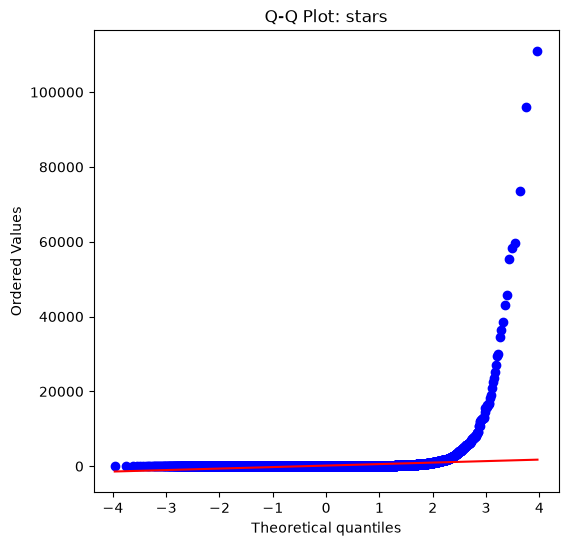

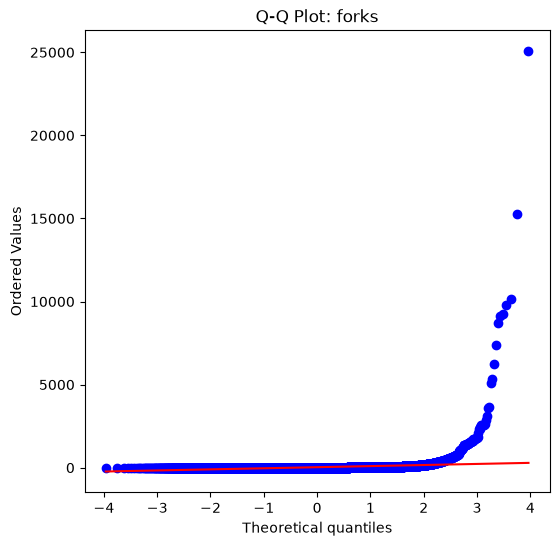

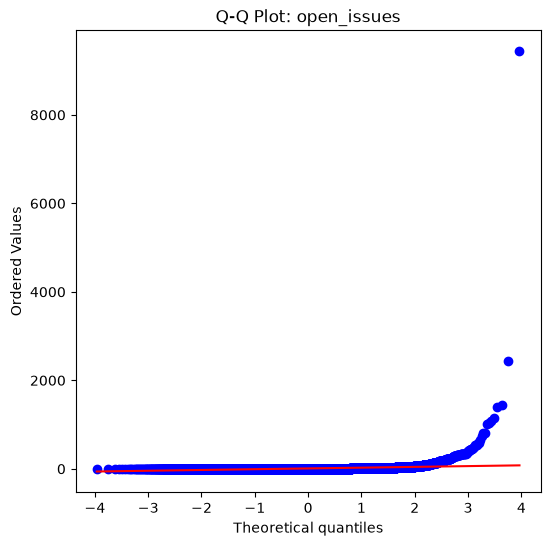

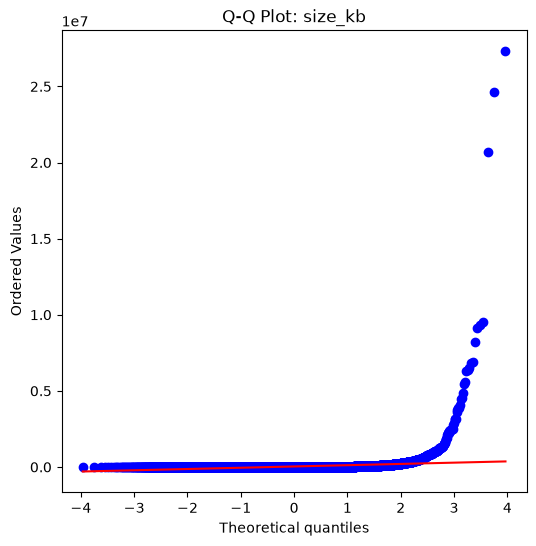

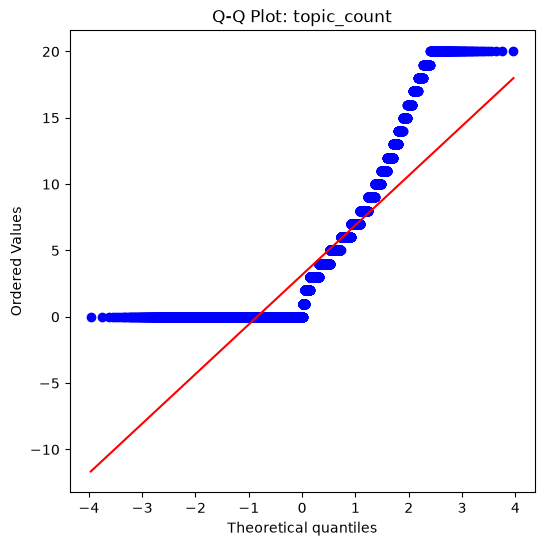

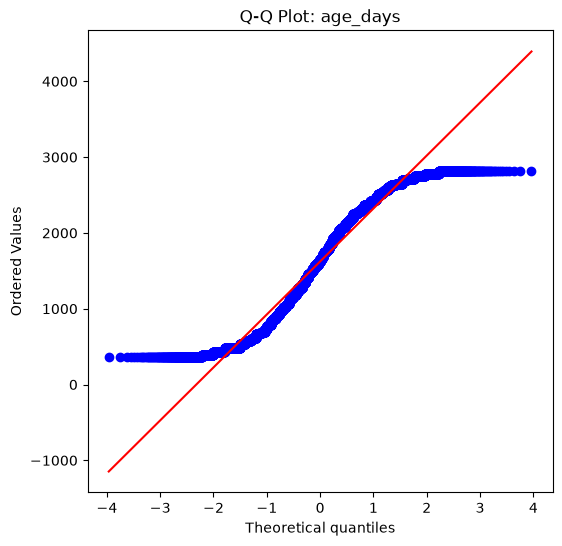

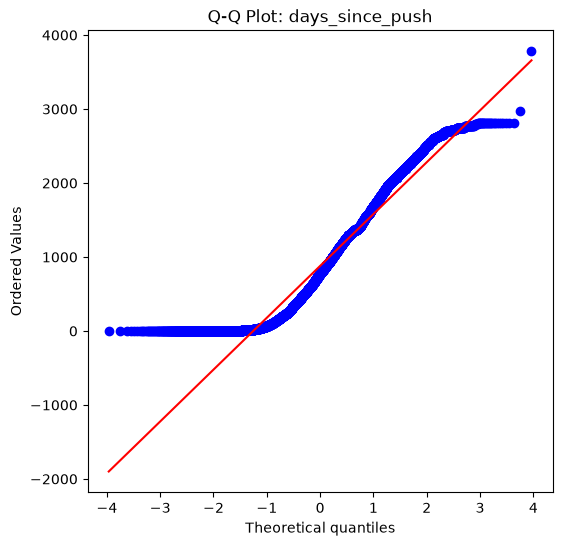

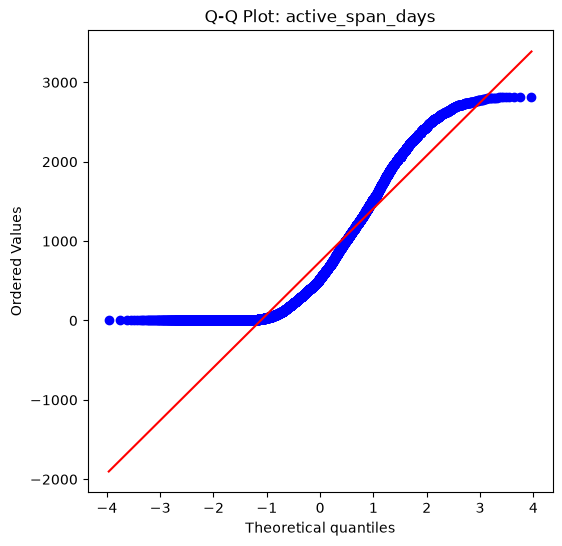

In [53]:
# S3.Step3.5 Q-Q Plots

for col in numeric_df.columns:

    plt.figure(figsize=(6,6))

    stats.probplot(
        numeric_df[col].dropna(),
        dist="norm",
        plot=plt
    )

    plt.title(f'Q-Q Plot: {col}')

    plt.show()

## Step 4: Shapiro-Wilk Normality Test

In [54]:
# S3.Step4.1 Shapiro-Wilk Normality Test

# Hypotheses
# --H₀: Data is normally distributed
# --H₁: Data is not normally distributed


for col in numeric_df.columns:

    sample = numeric_df[col].dropna()

    # Large datasets should be sampled
    if len(sample) > 5000:
        sample = sample.sample(5000, random_state=1)

    stat, p = shapiro(sample)

    print(f"\n{col}")
    print(f"Statistic = {stat:.4f}")
    print(f"P-value = {p:.4f}")

    if p > 0.05:
        print("Fail to reject H0 : approximately normal")
    else:
        print("Reject H0 : not normally distributed")


stars
Statistic = 0.0509
P-value = 0.0000
Reject H0 : not normally distributed

forks
Statistic = 0.0585
P-value = 0.0000
Reject H0 : not normally distributed

open_issues
Statistic = 0.1907
P-value = 0.0000
Reject H0 : not normally distributed

size_kb
Statistic = 0.1162
P-value = 0.0000
Reject H0 : not normally distributed

topic_count
Statistic = 0.7667
P-value = 0.0000
Reject H0 : not normally distributed

age_days
Statistic = 0.9537
P-value = 0.0000
Reject H0 : not normally distributed

days_since_push
Statistic = 0.9320
P-value = 0.0000
Reject H0 : not normally distributed

active_span_days
Statistic = 0.8850
P-value = 0.0000
Reject H0 : not normally distributed


In [55]:
# S3.Step4.2

# Hypotheses
# --H₀: Data is normally distributed
# --H₁: Data is not normally distributed

results = []

for col in numeric_df.columns:

    data = numeric_df[col].dropna()

    mean = data.mean()
    sem = stats.sem(data)

    ci = stats.t.interval(
        confidence=0.95,
        df=len(data)-1,
        loc=mean,
        scale=sem
    )

    results.append([
        col,
        round(mean, 2),
        round(ci[0], 2),
        round(ci[1], 2)
    ])

ci_df = pd.DataFrame(
    results,
    columns=['Variable', 'Mean', 'CI Lower', 'CI Upper']
)

display(ci_df)

,Variable,Mean,CI Lower,CI Upper
0,stars,177.38,152.40,202.36
1,forks,29.78,25.50,34.05
2,open_issues,8.85,7.72,9.98
3,size_kb,34752.79,29276.79,40228.78
4,topic_count,3.17,3.11,3.23
5,age_days,1623.20,1612.99,1633.42
6,days_since_push,879.50,869.13,889.87
7,active_span_days,743.33,733.23,753.42


In [56]:
# S3.Step4.3 95% Confidence Intervals

# Estimate the population mean for each variable.
for col in numeric_df.columns:

    data = numeric_df[col].dropna()

    mean = data.mean()
    sem = stats.sem(data)

    ci = stats.t.interval(
        confidence=0.95,
        df=len(data)-1,
        loc=mean,
        scale=sem
    )

    print(f"\n{col}")
    print(f"Mean = {mean:.2f}")
    print(f"95% CI = ({ci[0]:.2f}, {ci[1]:.2f})")


stars
Mean = 177.38
95% CI = (152.40, 202.36)

forks
Mean = 29.78
95% CI = (25.50, 34.05)

open_issues
Mean = 8.85
95% CI = (7.72, 9.98)

size_kb
Mean = 34752.79
95% CI = (29276.79, 40228.78)

topic_count
Mean = 3.17
95% CI = (3.11, 3.23)

age_days
Mean = 1623.20
95% CI = (1612.99, 1633.42)

days_since_push
Mean = 879.50
95% CI = (869.13, 889.87)

active_span_days
Mean = 743.33
95% CI = (733.23, 753.42)


In [57]:
# S3.Step4.4 One-Sample t-Test Example

# Determine whether the mean time since the last push differs from 365 days,
# the stale threshold used in the abandonment rule.

# Hypotheses
# --H₀: μ = 365
# --H₁: μ ≠ 365

stat, p = stats.ttest_1samp(
    df['days_since_push'].dropna(),
    popmean=365
)

print("Sample mean:", round(df['days_since_push'].mean(), 2))
print("T-statistic:", round(stat,4))
print("P-value:", round(p,4))

Sample mean: 879.5
T-statistic: 97.2376
P-value: 0.0


The sample mean of `days_since_push` is 879.5 days. The t-statistic is 97.24 and the p-value is below 0.0001, so H₀ is rejected. The result is expected with 18,866 observations, where even a small difference is detectable. The 365-day value is a rule threshold, not a population parameter, so this test only demonstrates the mechanics. The practical point is that the typical repository in this sample has gone about two and a half years without a push.

## Step 5: ANOVA

In [58]:
# S3.Step5.1 Compare Stars by Language

# ANOVA on log stars, because raw star counts are extremely skewed

df['log_stars'] = np.log1p(df['stars'])

groups = []

for category in df['language'].unique():

    groups.append(
        df[df['language']==category]
        ['log_stars']
        .dropna()
    )

f_stat, p_value = stats.f_oneway(*groups)

print("F-statistic:", round(f_stat,4))
print("P-value:", round(p_value,4))
display(df.groupby('language')['stars'].agg(['count', 'median', 'mean']).round(1))

F-statistic: 37.2142
P-value: 0.0


,count,median,mean
language,,,
Go,1379,29.0,271.3
Java,1096,21.5,69.1
JavaScript,3222,21.0,90.9
Python,8736,25.0,141.8
Rust,1165,28.0,329.6
TypeScript,3268,26.0,300.2


Interpretation
p < 0.05 → significant difference exists among groups
p ≥ 0.05 → no significant difference

The ANOVA on log stars gives F = 37.21 and p below 0.0001, so mean log stars differ by language. The medians are close (21.0 for JavaScript to 29.0 for Go), so the difference is small in practical terms. Means for Rust (329.6), TypeScript (300.2), and Go (271.3) are pulled up by a few very popular repositories. Log stars are still right skewed (skewness 1.66), so the normality assumption is not fully met. The Kruskal-Wallis test on raw stars in Step 7 gives the same conclusion (H = 144.37, p < 0.0001).

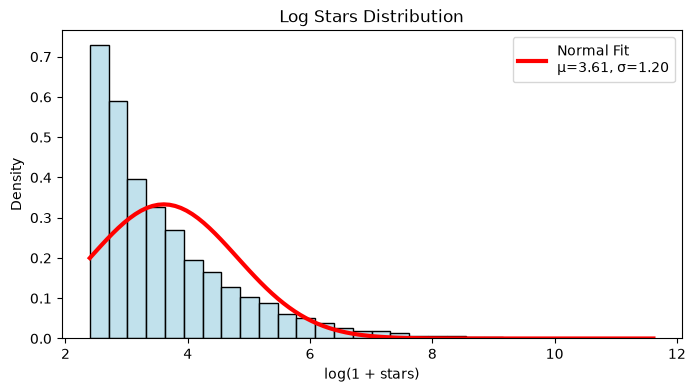

In [59]:
# S3.Step5.2 Fit a Normal Distribution

# Example using log stars. Raw stars are too skewed for a normal fit to be meaningful.

from scipy.stats import norm

data = df['log_stars'].dropna()

mu, sigma = norm.fit(data)

plt.figure(figsize=(8,4))

sns.histplot(
    data,
    stat='density',
    bins=30,
    color='lightblue'
)

x = np.linspace(data.min(), data.max(), 100)

pdf = norm.pdf(x, mu, sigma)

plt.plot(
    x,
    pdf,
    'r',
    linewidth=3,
    label=f'Normal Fit\nμ={mu:.2f}, σ={sigma:.2f}'
)

plt.title('Log Stars Distribution')
plt.xlabel('log(1 + stars)')
plt.legend()

plt.show()

## Step 6: Distribution Matrix for All Numerical Variables

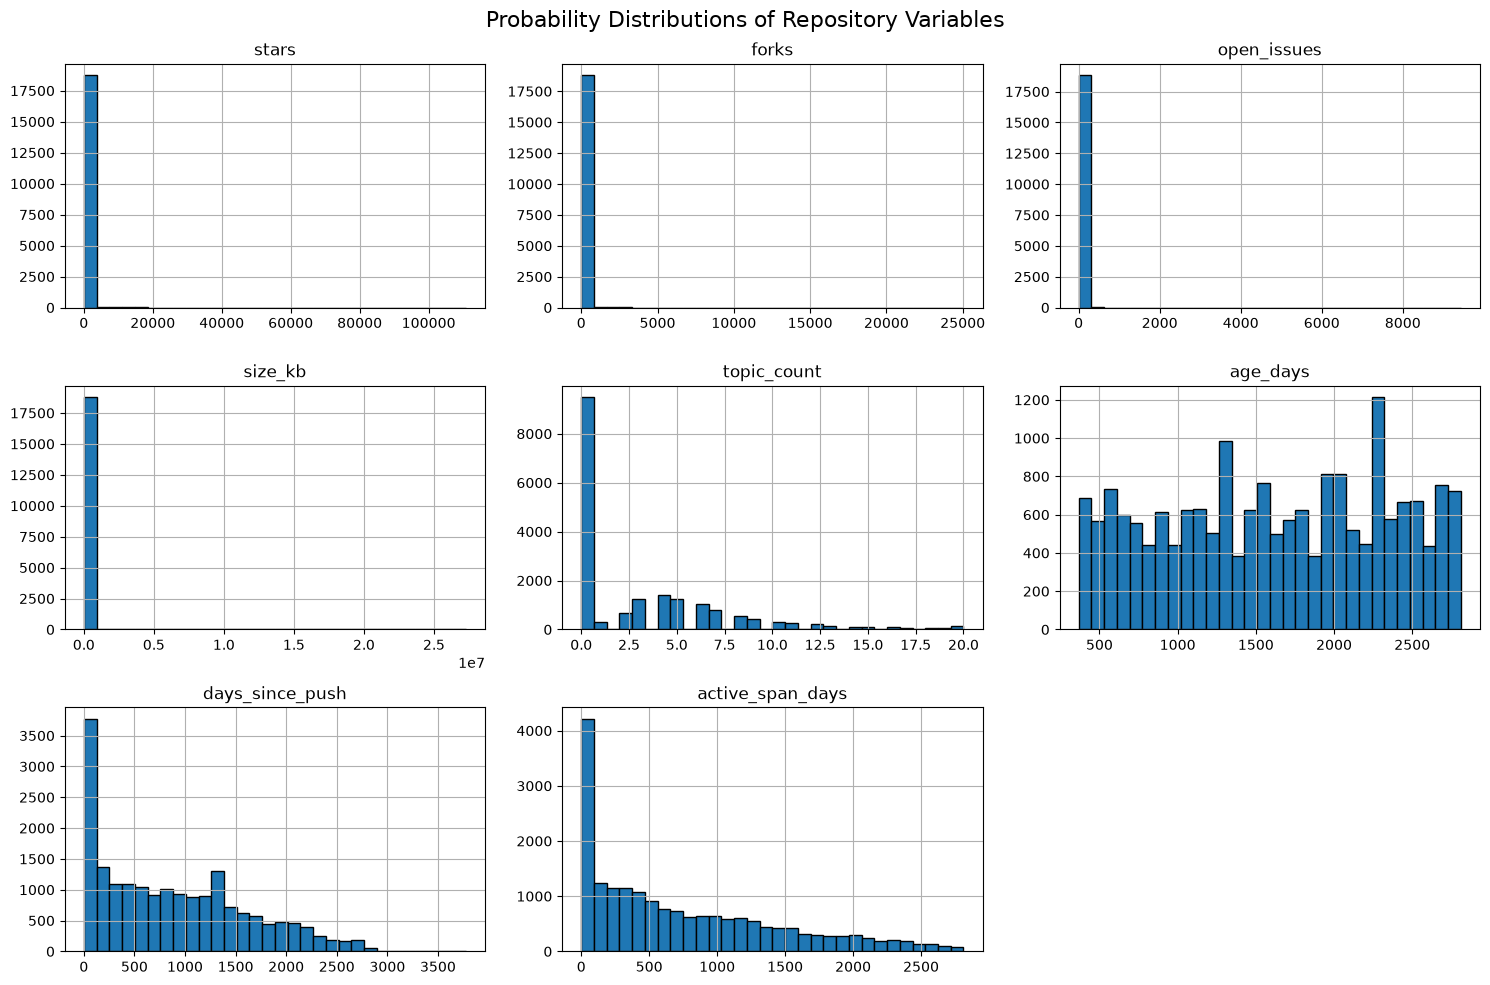

In [60]:
# S3.Step6.1 Fit a Normal Distribution

# A probability-distribution matrix often used in data mining.

numeric_df.hist(
    figsize=(15, 10),
    bins=30,
    edgecolor='black'
)

plt.suptitle(
    'Probability Distributions of Repository Variables',
    fontsize=16
)

plt.tight_layout()
plt.show()

## Step 7: Nonparametric Variables

Are there are variables that are best treated using nonparametric methods, either because they are categorical or because the numeric variables do not satisfy common parametric assumptions such as normality?<br>
<br>

The GitHub dataset contains several variables that are inherently nonparametric because they are categorical (nominal) rather than numerical. These should be analyzed using frequency distributions, percentages, cross-tabulations, and nonparametric statistical tests.<br>
<br>

| Variable | Data Type | Measurement Scale | Recommended Analysis |
|-----------|-----------|-------------------|----------------------|
| language | Categorical | Nominal | Frequency tables, pie charts, Chi-Square tests, Kruskal-Wallis tests |
| owner_type | Categorical | Nominal | Frequency tables, Mann-Whitney U tests |
| license | Categorical | Nominal | Frequency tables (long tail grouped) |
| maintenance_status | Categorical | Nominal | Frequency tables, Chi-Square tests |
| archived and other flags | Boolean | Nominal | Proportions, Chi-Square tests |

<br>

Numeric Variables That May Require Nonparametric Analysis<br>
<br>

The descriptive statistics in Section 2 show:
* extreme observations
* heavy right skew in every count variable
* a hard floor at 10 stars from the sampling design
* bounded ranges for the age variables, which cannot exceed the 2019 start of the sample<br>
<br>

Therefore, these variables may violate normality assumptions:
* stars
* forks
* open_issues
* size_kb
* topic_count
* age_days
* days_since_push
* active_span_days<br>
<br>

Common indicators include:
* Strong positive skewness
* Many outliers
* Non-normal Q-Q plots
* Significant Shapiro-Wilk test results

In [61]:
 # S3.Step7.1 How to Determine if Nonparametric Methods Are Needed

for col in numeric_df.columns:

    stat, p = stats.shapiro(
        numeric_df[col].dropna().sample(5000, random_state=1)
        if len(numeric_df[col].dropna()) > 5000
        else numeric_df[col].dropna()
    )

    print(f"{col}: p = {p:.4f}")

stars: p = 0.0000
forks: p = 0.0000
open_issues: p = 0.0000
size_kb: p = 0.0000
topic_count: p = 0.0000
age_days: p = 0.0000
days_since_push: p = 0.0000
active_span_days: p = 0.0000


Interpretation:

p > 0.05 → Parametric methods may be appropriate.

p ≤ 0.05 → Consider nonparametric methods.<br>
<br>


Nonparametric Tests You Could Include in the Lab:
* Mann-Whitney U Test
* Compare two groups.

In [62]:
# S3.Step7.2 Mann-Whitney U Test

# Do organization-owned repositories go longer or shorter without a push than user-owned ones?

# Import
from scipy.stats import mannwhitneyu

org = df[df['owner_type']=='Organization']['days_since_push']
user = df[df['owner_type']=='User']['days_since_push']

u_stat, p = mannwhitneyu(
    org,
    user,
    alternative='two-sided'
)

print("Median days since push, Organization:", org.median())
print("Median days since push, User:", user.median())
print("U-statistic:", u_stat)
print("p-value:", p)

Median days since push, Organization: 401.0
Median days since push, User: 896.0
U-statistic: 25737649.0
p-value: 1.3444874597946033e-204


In [63]:
# S3.Step7.3 Kruskal-Wallis Test
# --Compare more than two groups.

from scipy.stats import kruskal

groups = [
    grp['stars'].dropna()
    for _, grp in df.groupby('language')
]

h_stat, p = kruskal(*groups)

print("H-statistic:", h_stat)
print("p-value:", p)

H-statistic: 144.36597209236834
p-value: 2.1102637263849838e-29


In [64]:
# S3.Step7.4 Spearman Correlation
# --Nonparametric alternative to Pearson correlation.

from scipy.stats import spearmanr

for a, b in [('stars', 'forks'), ('stars', 'open_issues'), ('stars', 'days_since_push')]:
    corr, p = spearmanr(df[a], df[b])
    print(f"{a} vs {b}: Spearman = {corr:.4f}, p-value = {p:.4g}")

stars vs forks: Spearman = 0.6558, p-value = 0
stars vs open_issues: Spearman = 0.3688, p-value = 0
stars vs days_since_push: Spearman = -0.1999, p-value = 2.28e-169


In [65]:
# S3.Step7.5 Chi-Square Test of Independence
# --Is maintenance status independent of language? (labeled rows only)

from scipy.stats import chi2_contingency

labeled = df[df['maintenance_status'] != 'unlabeled']
table = pd.crosstab(labeled['language'], labeled['maintenance_status'])
display(table)
display((pd.crosstab(labeled['language'], labeled['maintenance_status'], normalize='index') * 100).round(1))

chi2, p, dof, _ = chi2_contingency(table)
print("Chi-square:", round(chi2, 4))
print("Degrees of freedom:", dof)
print("p-value:", p)

maintenance_status,abandoned,maintained
language,,
Go,512,409
Java,429,216
JavaScript,1576,429
Python,3836,1158
Rust,403,324
TypeScript,1318,791


maintenance_status,abandoned,maintained
language,,
Go,55.6,44.4
Java,66.5,33.5
JavaScript,78.6,21.4
Python,76.8,23.2
Rust,55.4,44.6
TypeScript,62.5,37.5


Chi-square: 408.7164
Degrees of freedom: 5
p-value: 3.9218662756214996e-86


## Recommendations

All eight numeric variables fail the Shapiro-Wilk test. With 5,000 sampled rows this is expected for count data, so the skewness and the Q-Q plots matter more than the p-values. The nonparametric results are:

* **Mann-Whitney U.** Organization-owned repositories have a shorter median gap since the last push (401 days) than user-owned ones (896 days), p < 0.0001.
* **Kruskal-Wallis.** Stars differ by language (H = 144.37, p < 0.0001).
* **Spearman.** Stars correlate with forks (0.656), with open issues (0.369), and weakly and negatively with days since last push (-0.200).
* **Chi-square.** Maintenance status is not independent of language (chi-square = 408.72, 5 degrees of freedom, p < 0.0001). The abandoned share among labeled repositories is 55.4% for Rust, 55.6% for Go, 62.5% for TypeScript, 66.5% for Java, 76.8% for Python, and 78.6% for JavaScript. This test does not control for repository age, and the language mix differs by creation year.

Abandonment also depends strongly on creation year. Among labeled repositories the abandoned share falls from 83.6% for 2019 to 38.3% for 2025. Part of that is age: older repositories have had more time to go stale. `created_year` is kept in the final file, so a model that uses it will partly learn age. The time-based split in the proposal addresses this.

Parametric
* Confidence Intervals
* t-tests
* ANOVA (on log-transformed counts)
* Pearson Correlation (on log-transformed counts)

Nonparametric

* Mann-Whitney U Test
* Kruskal-Wallis Test
* Spearman Correlation
* Chi-Square Test (language by maintenance status)

### Categories of `language`

| Category | Description |
|-----------|-------------|
| `Python` | Primary language Python |
| `JavaScript` | Primary language JavaScript |
| `TypeScript` | Primary language TypeScript |
| `Go` | Primary language Go |
| `Rust` | Primary language Rust |
| `Java` | Primary language Java |

### Why is This Variable Nonparametric?
- It contains categories rather than numerical measurements.
- Mean, median, standard deviation, variance, skewness, and kurtosis are not meaningful.
- Analyses are based on counts, percentages, and category comparisons rather than numerical distributions.
- Nonparametric statistical tests are appropriate when comparing groups defined by this variable.

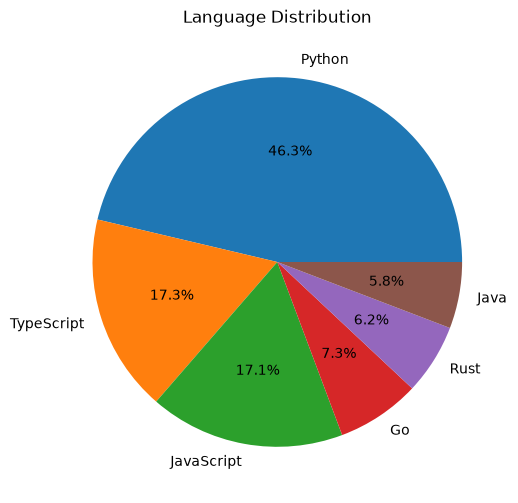

In [66]:
### Example Analysis

# Frequency counts

df['language'].value_counts()

# Percentage distribution
round(df['language'].value_counts(normalize=True) * 100, 2)

# Pie chart
df['language'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)

plt.title('Language Distribution')

plt.ylabel('')

plt.show()

## Step 8: Data Transformation

Four transformations prepare the data for modeling:

1. Log transform (`log1p`) of the count variables to reduce right skew. Box-Cox is shown for comparison on `stars`, which is strictly positive.
2. Derived ratio `fork_star_ratio`, listed in the proposal as an abandonment feature.
3. One-hot encoding of `language`, `owner_type`, and a grouped `license`.
4. Standardization (z-scores) of the log features so no single scale dominates distance-based methods.

The description text is also cleaned for the clustering step: lowercased, with URLs and extra whitespace removed, and topics appended.

,Raw skew,Log skew
stars,36.87,1.66
forks,48.67,0.90
open_issues,92.60,1.04
size_kb,46.54,0.11
topic_count,1.60,0.39


Box-Cox lambda for stars = -0.520, skew after Box-Cox = 0.26


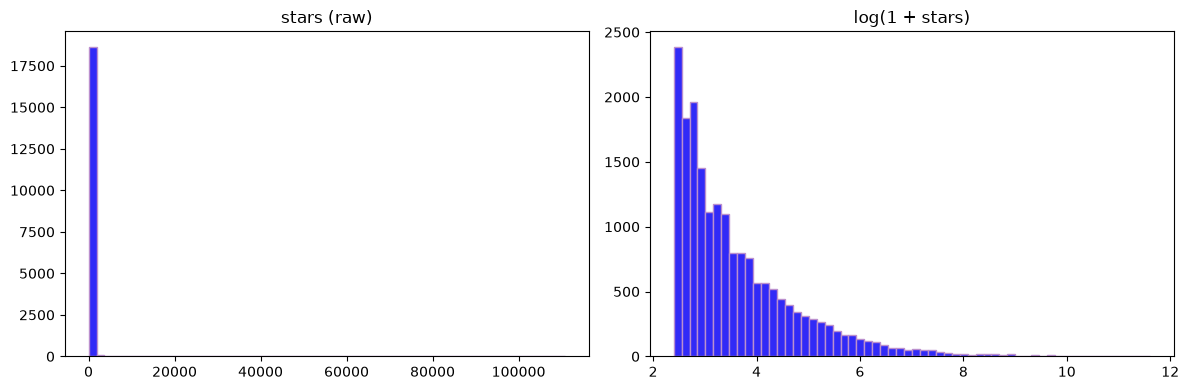

In [67]:
# S3.Step8.1 Log and Box-Cox transforms

skewed = ['stars', 'forks', 'open_issues', 'size_kb', 'topic_count']
for col in skewed:
    df[f'log_{col}'] = np.log1p(df[col])

bc_stars, bc_lambda = boxcox(df['stars'])

skew_table = pd.DataFrame({
    'Raw skew': df[skewed].skew(),
    'Log skew': df[[f'log_{c}' for c in skewed]].skew().values
}).round(2)
display(skew_table)
print(f"Box-Cox lambda for stars = {bc_lambda:.3f}, skew after Box-Cox = {pd.Series(bc_stars).skew():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['stars'], bins=60, color=graph_color, edgecolor=edgecolor)
axes[0].set_title('stars (raw)')
axes[1].hist(df['log_stars'], bins=60, color=graph_color, edgecolor=edgecolor)
axes[1].set_title('log(1 + stars)')
plt.tight_layout()
plt.show()

In [68]:
# S3.Step8.2 Derived ratio and text cleaning

import re

df['fork_star_ratio'] = df['forks'] / df['stars']

def clean_text(desc, topics):
    text = f"{desc} {topics.replace(';', ' ')}".lower()
    text = re.sub(r'https?://\S+', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

df['text'] = [clean_text(d, t) for d, t in zip(df['description'], df['topics'])]
display(df[['description', 'topics', 'text']].head())
display(df['fork_star_ratio'].describe().round(3).to_frame())

,description,topics,text
repo_id,,,
165957180,Data Migration Platform,hacktoberfest,data migration platform hacktoberfest
166091373,"Extract indicators of compromise from text, in...",command-line;command-line-tool;data-mining;def...,"extract indicators of compromise from text, in..."
165960557,A slick BTree on disk based key value store im...,database;embedded-database;go;golang;key-value...,a slick btree on disk based key value store im...
166055089,"Gowog, Golang based Web multiplayer Online Game",game;game-2d;golang;online-game;phaser;webgame...,"gowog, golang based web multiplayer online gam..."
166048649,A Go type to prevent internal numeric IDs from...,golang;id;json;type,a go type to prevent internal numeric ids from...


,fork_star_ratio
count,18866.000
mean,0.280
std,0.994
min,0.000
25%,0.074
50%,0.158
75%,0.300
max,74.347


In [69]:
# S3.Step8.3 One-hot encoding

top_licenses = ['MIT', 'Apache-2.0', 'GPL-3.0', 'None']
df['license_group'] = df['license'].where(df['license'].isin(top_licenses), 'Other')

encoder = OneHotEncoder(sparse_output=False)
encoded = encoder.fit_transform(df[['language', 'owner_type', 'license_group']])
encoded_df = pd.DataFrame(
    encoded.astype(int),
    columns=encoder.get_feature_names_out(),
    index=df.index
)
display(encoded_df.head())
print(encoded_df.shape)

,language_Go,language_Java,language_JavaScript,language_Python,language_Rust,language_TypeScript,owner_type_Organization,owner_type_User,license_group_Apache-2.0,license_group_GPL-3.0,license_group_MIT,license_group_None,license_group_Other
repo_id,,,,,,,,,,,,,
165957180,1,0,0,0,0,0,1,0,1,0,0,0,0
166091373,1,0,0,0,0,0,0,1,0,0,1,0,0
165960557,1,0,0,0,0,0,0,1,0,0,0,1,0
166055089,1,0,0,0,0,0,0,1,0,0,1,0,0
166048649,1,0,0,0,0,0,1,0,0,0,1,0,0


(18866, 13)


In [70]:
# S3.Step8.4 Standardization

from sklearn.preprocessing import StandardScaler

scale_cols = ['log_stars', 'log_forks', 'log_open_issues', 'log_size_kb', 'log_topic_count',
              'fork_star_ratio', 'age_days', 'days_since_push', 'active_span_days']

scaler = StandardScaler()
scaled_df = pd.DataFrame(
    scaler.fit_transform(df[scale_cols]),
    columns=[f'z_{c}' for c in scale_cols],
    index=df.index
)
display(scaled_df.describe().round(2))

,z_log_stars,z_log_forks,z_log_open_issues,z_log_size_kb,z_log_topic_count,z_fork_star_ratio,z_age_days,z_days_since_push,z_active_span_days
count,18866.00,18866.00,18866.00,18866.00,18866.00,18866.00,18866.00,18866.00,18866.00
mean,0.00,-0.00,-0.00,0.00,0.00,-0.00,-0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.01,-1.49,-0.95,-2.43,-0.93,-0.28,-1.75,-1.21,-1.05
25%,-0.75,-0.65,-0.95,-0.76,-0.93,-0.21,-0.83,-0.92,-0.87
50%,-0.29,-0.12,-0.38,-0.01,-0.93,-0.12,0.05,-0.15,-0.30
75%,0.45,0.53,0.65,0.73,0.87,0.02,0.90,0.67,0.63
max,6.69,6.24,6.58,3.74,2.12,74.54,1.66,3.99,2.92


## Step 9: Data Reduction

Reduction happens at three levels:

1. Attribute removal: drop identifiers, constants, raw columns replaced by transformed versions, and fields that leak the label.
2. Correlation and variance checks on the remaining features.
3. Principal component analysis to see how much of the numeric variation a few components capture.

,Percent True
has_homepage,29.3
has_wiki,80.7
has_pages,10.8
has_discussions,9.5
archived,6.6


Distinct snapshot_date values: 1


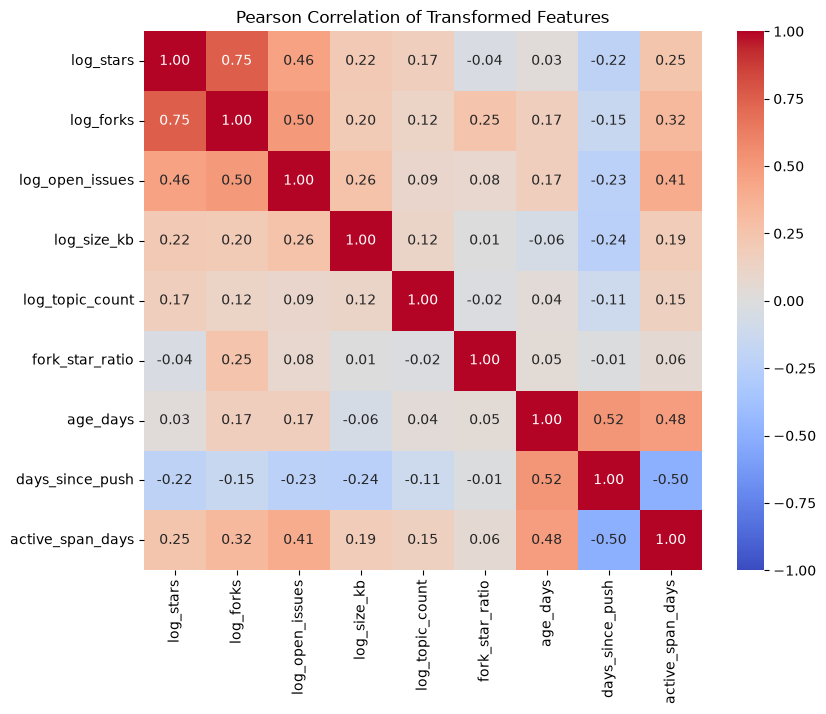

Pairs with |r| > 0.8: []
Strongest pairs:
log_stars        log_forks           0.75
age_days         days_since_push     0.52
days_since_push  active_span_days    0.50
log_forks        log_open_issues     0.50
age_days         active_span_days    0.48
dtype: float64
Rows where the identity fails by more than one day: 6
Rows where pushed_at is earlier than created_at: 6


maintenance_status,abandoned,maintained
created_year,,
2019,83.6,16.4
2020,80.0,20.0
2021,73.9,26.1
2022,71.9,28.1
2023,66.6,33.4
2024,59.7,40.3
2025,38.3,61.7


In [71]:
# S3.Step9.1 Near-constant and redundant attributes

flags = ['has_homepage', 'has_wiki', 'has_pages', 'has_discussions', 'archived']
display((df[flags].mean() * 100).round(1).to_frame('Percent True'))
print('Distinct snapshot_date values:', df['snapshot_date'].nunique())

corr = df[scale_cols].corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Pearson Correlation of Transformed Features')
plt.show()

high = [(a, b, round(corr.loc[a, b], 2)) for i, a in enumerate(scale_cols)
        for b in scale_cols[i + 1:] if abs(corr.loc[a, b]) > 0.8]
print('Pairs with |r| > 0.8:', high)

pairs = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1)).stack().abs().sort_values(ascending=False)
print('Strongest pairs:')
print(pairs.head(5).round(2))

# Identity: days_since_push = age_days - active_span_days, except where pushed_at predates created_at (imported history)
gap = (df['age_days'] - df['active_span_days'] - df['days_since_push']).abs()
print('Rows where the identity fails by more than one day:', (gap > 1).sum())
print('Rows where pushed_at is earlier than created_at:', (df['pushed_at'] < df['created_at']).sum())

# Label share by creation year: older repositories have had longer to go stale
labeled_year = df[df['maintenance_status'] != 'unlabeled']
display((pd.crosstab(labeled_year['created_year'], labeled_year['maintenance_status'], normalize='index') * 100).round(1))

No pair of features has a correlation above 0.8. The strongest pair is `log_stars` and `log_forks` (0.75), followed by `age_days` and `days_since_push` (0.52). All five boolean flags vary, and `snapshot_date` is constant.

Reduction decisions:

* **Constant column.** `snapshot_date` is dropped, since it has one value.
* **Identifiers and free text.** `repo_id` stays as the index. `full_name` is kept for traceability only. `description` and `topics` are combined into `text` for clustering.
* **Raw counts.** Only the log versions are used as model inputs.
* **`updated_at` and `has_wiki`.** Both are dropped. `updated_at` changes when a repository is starred, and `has_wiki` is on by default for 81% of repositories.
* **Label leakage.** `days_since_push` and `active_span_days` are dropped as predictors. The label is built from `days_since_push`, and `days_since_push = age_days - active_span_days` for all but 6 repositories in the cleaned data, whose push predates creation. Keeping `active_span_days` beside `age_days` would let a model reconstruct the label.

,Component,Explained,Cumulative
0,PC1,0.309,0.309
1,PC2,0.175,0.484
2,PC3,0.125,0.609
3,PC4,0.115,0.724
4,PC5,0.102,0.827
5,PC6,0.093,0.920
6,PC7,0.060,0.979
7,PC8,0.021,1.000
8,PC9,0.000,1.000


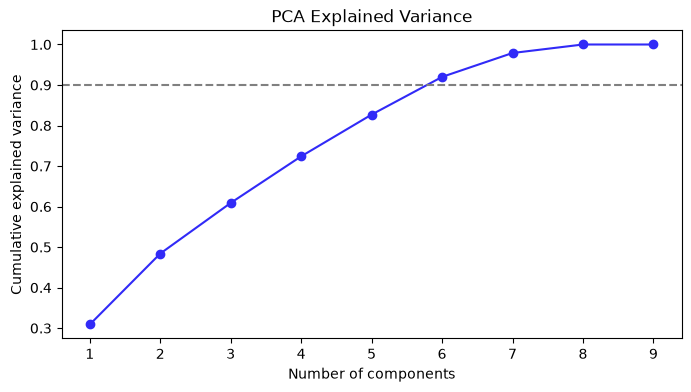

In [72]:
# S3.Step9.2 PCA on the standardized features

from sklearn.decomposition import PCA

pca = PCA()
pca.fit(scaled_df)
explained = pd.DataFrame({
    'Component': [f'PC{i + 1}' for i in range(len(pca.explained_variance_ratio_))],
    'Explained': pca.explained_variance_ratio_.round(3),
    'Cumulative': pca.explained_variance_ratio_.cumsum().round(3)
})
display(explained)

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(explained) + 1), explained['Cumulative'], marker='o', color=graph_color)
plt.axhline(0.9, color='gray', linestyle='--')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.title('PCA Explained Variance')
plt.show()

The first component explains 30.9% of the variance and six components explain 92.0%. Variance is spread fairly evenly, so PCA offers little compression and all standardized features are kept. The ninth component has almost no variance because `age_days`, `days_since_push`, and `active_span_days` are nearly linearly dependent. That is the same identity that caused the leakage problem above.

## Step 10: Final Dataset Preparation

In [73]:
# S3.Step10.1 Assemble and save the analysis-ready dataset

keep = ['full_name', 'language', 'owner_type', 'license_group', 'created_year', 'text',
        'stars', 'forks', 'open_issues', 'has_homepage', 'has_pages', 'has_discussions',
        'maintenance_status']

final_df = pd.concat([df[keep], scaled_df, encoded_df], axis=1)

# Label-defining fields stay out of the predictors to avoid leakage.
# active_span_days is dropped too: days_since_push = age_days - active_span_days,
# so keeping it beside age_days would let a model rebuild the label. Both are removed.
final_df = final_df.drop(columns=['z_days_since_push', 'z_active_span_days'])

print(final_df.shape)
print('Missing values:', final_df.isnull().sum().sum())
display(final_df['maintenance_status'].value_counts().to_frame('Frequency'))
display(final_df.head())

final_df.to_csv('github_repos_clean.csv')
print('Saved github_repos_clean.csv')

(18866, 33)
Missing values: 0


,Frequency
maintenance_status,
abandoned,8074
unlabeled,7465
maintained,3327


,full_name,language,owner_type,license_group,created_year,text,stars,forks,open_issues,has_homepage,has_pages,has_discussions,maintenance_status,z_log_stars,z_log_forks,z_log_open_issues,z_log_size_kb,z_log_topic_count,z_fork_star_ratio,z_age_days,language_Go,language_Java,language_JavaScript,language_Python,language_Rust,language_TypeScript,owner_type_Organization,owner_type_User,license_group_Apache-2.0,license_group_GPL-3.0,license_group_MIT,license_group_None,license_group_Other
repo_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
165957180,pingcap/dm,Go,Organization,Apache-2.0,2019,data migration platform hacktoberfest,454,189,127,False,False,False,abandoned,2.097807,2.518477,3.043886,1.078598,-0.232248,0.136942,1.65924,1,0,0,0,0,0,1,0,1,0,0,0,0
166091373,assafmo/xioc,Go,User,MIT,2019,"extract indicators of compromise from text, in...",163,9,4,False,False,False,abandoned,1.245531,0.271396,0.375909,-1.115629,1.782111,-0.226468,1.65924,1,0,0,0,0,0,0,1,0,0,1,0,0
165960557,naqvijafar91/cuteDB,Go,User,None,2019,a slick btree on disk based key value store im...,150,26,5,False,False,False,abandoned,1.176553,1.029407,0.525922,-0.219757,1.271424,-0.107589,1.65924,1,0,0,0,0,0,0,1,0,0,0,1,0
166055089,giongto35/gowog,Go,User,MIT,2019,"gowog, golang based web multiplayer online gam...",126,30,0,True,False,False,unlabeled,1.031984,1.134838,-0.948323,0.678094,1.153672,-0.042410,1.65924,1,0,0,0,0,0,0,1,0,0,1,0,0
166048649,emvi/hide,Go,Organization,MIT,2019,a go type to prevent internal numeric ids from...,73,6,1,False,False,False,abandoned,0.580868,-0.000804,-0.378007,-0.558984,0.683796,-0.199318,1.65924,1,0,0,0,0,0,1,0,0,0,1,0,0


Saved github_repos_clean.csv


The final dataset has 18,866 rows and 33 columns plus the `repo_id` index, with no missing values. Of these rows, 8,074 (42.8%) are labeled abandoned, 3,327 (17.6%) are labeled maintained, and 7,465 (39.6%) are unlabeled. Only the 11,401 labeled rows are used to train the classifier. Among them 70.8% are abandoned, so the classes are imbalanced and the evaluation should report precision and recall, not accuracy alone. The saved file is `github_repos_clean.csv`.

<a name="p4"></a>

---

# Section 4: Modeling
---

Modeling is outside the scope of this preprocessing lab. The cleaned dataset feeds the research project's abandonment classifier (RQ2) and description clustering (RQ1).

<a name="p5"></a>

---

# Section 5: Evaluation
---

Evaluation is outside the scope of this preprocessing lab.

<a name="p6"></a>

---

# Section 6: Conclusion
---

The dataset is usable for the research project's repository-level work, with limits. The sample has 25,173 repositories, below the 30,000 to 50,000 target in the proposal, and 18,866 remain after cleaning. It has no README text, issue titles, contributor counts, or response times. The abandonment label is therefore an approximation of the proposal's rules, using archived status, last push, and open issues. Skew in every count variable calls for log transforms. Age confounds abandonment, so evaluation should use a time-based split.

<a name="p7"></a>

---

# Section 7: Assignment
---

## Dataset Description

**Source.** GitHub REST API, repository search endpoint (https://docs.github.com/en/rest/search). Collected on September 28, 2026 by `collect.py`. Raw JSON responses were saved so the snapshot is fixed. Data is public and collected under the GitHub terms of service.

**Sampling.** Repositories created from January 1, 2019 to September 27, 2025, at least 10 stars, not forks, primary language Python, JavaScript, TypeScript, Go, Rust, or Java. One creation day per calendar month was drawn at random (seed 4230) and every qualifying repository created that day was collected. This gives a day-cluster sample across 81 months. The end date is exactly one year before the snapshot, so every repository is old enough to meet the 365-day abandonment rule. Taking the first page of results for a whole month was rejected because the API orders results by popularity, which returned only the most-starred repositories.

**Data dictionary.** See Section 1 for the raw variables. Derived variables:

| Variable | Description |
|-----------|-------------|
| age_days | Days from creation to the snapshot date |
| days_since_push | Days from the last push to the snapshot date |
| active_span_days | Days from creation to the last push |
| created_year | Year of creation |
| maintenance_status | abandoned, maintained, or unlabeled (rules in Section 3, Step 3) |
| log_* | `log(1 + x)` of each count variable |
| fork_star_ratio | forks divided by stars |
| license_group | MIT, Apache-2.0, GPL-3.0, None, or Other |
| text | Cleaned lowercase description plus topics |
| z_* | Standardized versions of the log, ratio, and age features |
| language_*, owner_type_*, license_group_* | One-hot indicator columns |

**Preprocessing summary.**

1. **Missing values.** Dropped 4,009 rows with a missing description or language. Filled missing `license` with `None` and missing `topics` with an empty string.
2. **Duplicates.** None found.
3. **Filtering.** Removed 7 empty repositories and 2,291 mostly non-English descriptions, leaving 18,866 rows (75% of the raw file).
4. **Outliers.** Kept. Extreme star, fork, and issue counts are real and are the demand signal for the project.
5. **Derived features.** `age_days`, `days_since_push`, `active_span_days`, `created_year`, `fork_star_ratio`, and the `maintenance_status` label.
6. **Transformation.** `log1p` on count variables (stars skew 36.87 to 1.66), one-hot encoding of language, owner type, and grouped license, and z-score standardization of numeric features.
7. **Reduction.** Dropped the constant snapshot date, `updated_at`, `has_wiki`, and label-defining activity features. PCA showed little redundancy, so no components were substituted for the features.
8. **Known limits.** The English filter is an ASCII proxy. The 90-day and 365-day label thresholds come from the proposal, not from tuning. `created_year` is kept as a column and correlates with the label.